## Figure 1


In [2]:
from pathlib import Path
from importlib.metadata import version

assert version("scikit-learn") == "1.3.2", "Use scikit-learn 1.3.2 to reproduce the published RF predictions"
DATA_DIR = Path("../data")  # Change this if the repository data folder is stored elsewhere.
REPRO_OUTPUT_DIR = Path("results")
assert (DATA_DIR / "naffinity_dataset.csv").is_file(), "Set DATA_DIR to the folder containing the supplied data files."
REPRO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
import os
import re
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


# Directory setup
root_dir = str(REPRO_OUTPUT_DIR)

output_csv_path = os.path.join(root_dir, "processed_affinity_data.csv")
npy_save_path = os.path.join(root_dir, 'processed_affinity_data_MACCS.npy')
tSNE_output_path = os.path.join(root_dir, 'tSNE_RR-80P.csv')

# ============================================================
# Load finalized NAffinity v3 dataset
# ============================================================

dataset_path = str(DATA_DIR / "naffinity_dataset.csv")

df = pd.read_csv(dataset_path)

# Remove metadata and targets
drop_cols = [
    "Label",
    "AffinityValue",
    "ComplexID",
    "Folder",
    "Split"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
]

X = df[feature_cols].copy()

# Remove constant columns
train_features = X.loc[df["Split"].eq("Train")]
nunique = train_features.nunique(dropna=False)
X = X.loc[:, nunique > 1]

# Spearman correlation filtering
corr_matrix = train_features[X.columns].corr(method="spearman").abs()

upper_tri = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    col
    for col in upper_tri.columns
    if (upper_tri[col] > 0.75).any()
]

X = X.drop(columns=to_drop)

print(f"Features before filtering: {len(feature_cols)}")
print(f"Features after filtering: {X.shape[1]}")
assert X.shape[1] == 131, "Expected the 131 final model features"

fingerprints = X.values.astype(np.float32)

np.save(
    npy_save_path,
    fingerprints
)

print(
    f"Saved feature matrix: "
    f"{fingerprints.shape}"
)

# Sampling
fingerprints = np.load(npy_save_path)
strat_samp = np.flatnonzero(df["Split"].eq("Stratified").to_numpy())
assert len(strat_samp) == 117, "Expected 117 final stratified test complexes"

# Load the two-dimensional coordinates used for the published Figure 1.
published_tsne = pd.read_csv(DATA_DIR / "figure_1_coordinates.csv")
expected_split = df["Split"].map({"Train": "Total", "Stratified": "Strat"})
assert len(published_tsne) == len(df)
assert published_tsne["Split"].equals(expected_split)
X_tsne = published_tsne[["tSNE1", "tSNE2"]].to_numpy()


Features before filtering: 302
Features after filtering: 131
Saved feature matrix: (1179, 131)


In [4]:
# Save t-SNE coordinates

tsne_df = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])
tsne_df['Split'] = np.where(df['Split'].eq('Stratified'), 'Strat', 'Total')
tsne_df['Folder'] = df['Folder'].to_numpy()
assert tsne_df['Folder'].is_unique
tsne_df.to_csv(tSNE_output_path, index=False)
print(f"✅ tSNE coordinates saved to: {tSNE_output_path}")



✅ tSNE coordinates saved to: results/tSNE_RR-80P.csv


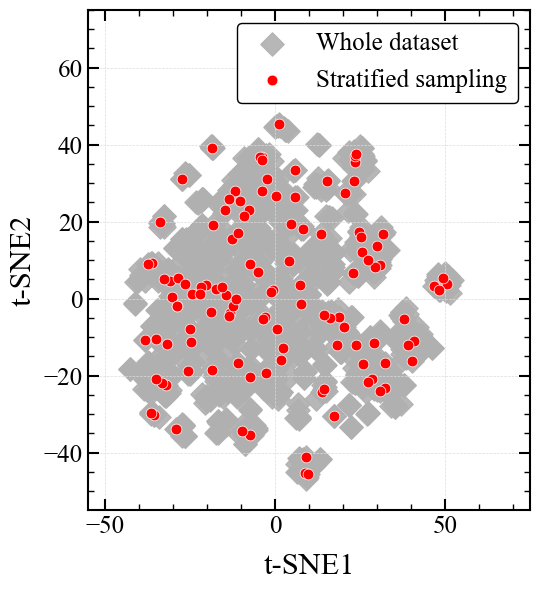

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Set global font to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Adjust figure size to match the taller/squarish aspect ratio
plt.figure(figsize=(5.5, 6))  

# Plotting the whole dataset as large gray diamonds
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], 
    c='#B0B0B0', marker='D', s=140, 
    label='Whole dataset', alpha=0.9
)

# Plotting the stratified sampling as prominent red dots with a light border
plt.scatter(
    X_tsne[strat_samp, 0], X_tsne[strat_samp, 1], 
    c='red', marker='o', s=60, 
    edgecolors='white', linewidths=0.5, 
    label='Stratified sampling', zorder=3
)

# Labels and tick adjustments
plt.xlabel('t-SNE1', fontsize=22, labelpad=10)
plt.ylabel('t-SNE2', fontsize=22, labelpad=5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Configure the grid to be very subtle and light behind the data
plt.grid(True, linestyle='--', linewidth=0.5, color='gainsboro', zorder=0)

# Main axis spine properties
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Force ticks to point INWARD and appear on all 4 sides (top, bottom, left, right)
ax.tick_params(direction='in', top=True, right=True, width=1.5, length=8, labelsize=18)

# Add minor ticks pointing inward on all sides
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', top=True, right=True, width=1.0, length=4)

# Set exact axis limits if needed to give breathing room (optional adjustments)
plt.xlim(-55, 75)
plt.ylim(-55, 75)

# Place legend cleanly inside the top-right corner with a white background and border
plt.legend(
    fontsize=18, 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1
)

plt.tight_layout()

# Save with high resolution
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_1_tSNE_stratified.png"), dpi=1200)
plt.show()

In [6]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")



Train rows: 1062 | Test rows: 117 | Raw features: 302

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.8120
  Precision: 0.6792
  Recall   : 0.8780
  F1 Score : 0.7660


## Table 1 and 2


In [7]:
label_map = {
    0: "Weak Binders (≥1 μM)",
    1: "Strong Binders (<1 μM)"
}

y_test_named = y_test.map(label_map)
rf_named = pd.Series(rf_preds).map(label_map)

print(
    "\n"
    + classification_report(
        y_test_named,
        rf_named,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

accuracy_weak = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

accuracy_strong = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print(
    "\n📊 Confusion Matrix "
    "(rows=true, cols=pred; order=[Weak, Strong])"
)
print(cm)

print("\n📊 Per-Class Accuracy:")
print(
    f"  Weak Binders (≥1 μM):   "
    f"{accuracy_weak:.4f}"
)
print(
    f"  Strong Binders (<1 μM): "
    f"{accuracy_strong:.4f}"
)

# ============================================================
# Additional probability diagnostics
# ============================================================
print("\n📈 Probability Summary")
print(
    f"Mean predicted strong-binding probability: "
    f"{rf_probs.mean():.4f}"
)

print(
    f"Predicted strong binders @ threshold "
    f"{OPTIMAL_THRESHOLD}: "
    f"{rf_preds.sum()} / {len(rf_preds)} "
    f"({100 * rf_preds.mean():.1f}%)"
)


                        precision    recall  f1-score   support

Strong Binders (<1 μM)     0.6792    0.8780    0.7660        41
  Weak Binders (≥1 μM)     0.9219    0.7763    0.8429        76

              accuracy                         0.8120       117
             macro avg     0.8006    0.8272    0.8044       117
          weighted avg     0.8369    0.8120    0.8159       117


📊 Confusion Matrix (rows=true, cols=pred; order=[Weak, Strong])
[[59 17]
 [ 5 36]]

📊 Per-Class Accuracy:
  Weak Binders (≥1 μM):   0.7763
  Strong Binders (<1 μM): 0.8780

📈 Probability Summary
Mean predicted strong-binding probability: 0.3790
Predicted strong binders @ threshold 0.38: 53 / 117 (45.3%)


## Figure 2


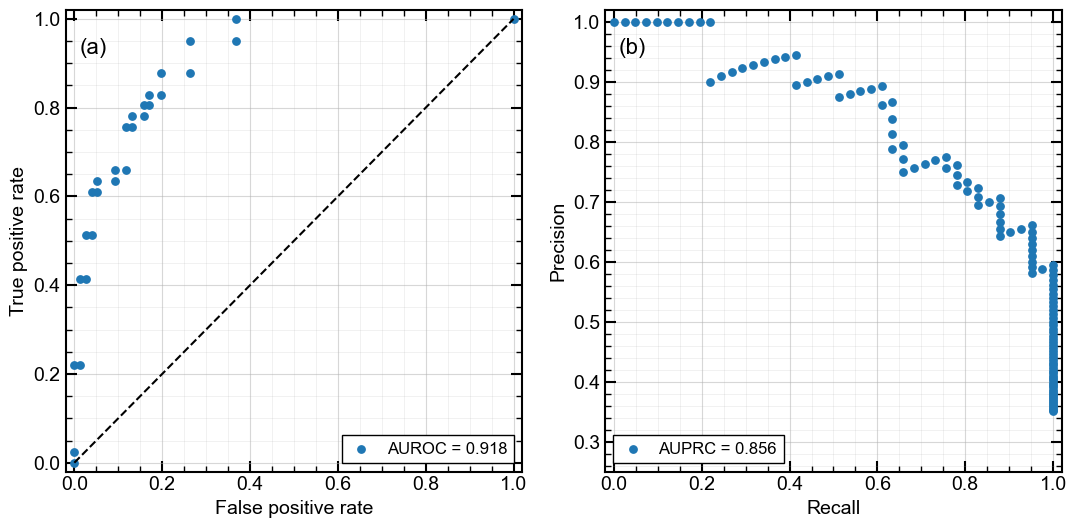

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from matplotlib.ticker import AutoMinorLocator

# ============================================================
# Origin-Style Global Plot Settings
# ============================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 14,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 8,
    'xtick.major.width': 1.5,
    'ytick.major.size': 8,
    'ytick.major.width': 1.5,
    'xtick.minor.size': 4,
    'xtick.minor.width': 1.0,
    'ytick.minor.size': 4,
    'ytick.minor.width': 1.0,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'legend.framealpha': 1.0,
    'legend.fontsize': 12
})

# ============================================================
# Assumes these already exist:
#   rf_pipeline
#   X_test_raw
#   y_test
# ============================================================

# Predicted probabilities
y_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]

# ============================================================
# ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# ============================================================
# Precision-Recall Curve
# ============================================================
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

# ============================================================
# Helper styling
# ============================================================
def apply_origin_styling(ax, xlim=(-0.02, 1.02), ylim=(-0.02, 1.02)):
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linewidth=0.8, alpha=0.5)
    ax.grid(True, which='minor', linewidth=0.5, alpha=0.25)

# ============================================================
# Combined ROC + PR Figure
# ============================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5.5)
)

# ============================================================
# Panel A - ROC
# ============================================================
ax = axes[0]

ax.scatter(
    fpr,
    tpr,
    label=f"AUROC = {roc_auc:.3f}",
    s=28
)

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.5
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")

ax.legend(
    loc="lower right",
    handlelength=1.5
)

apply_origin_styling(
    ax,
    xlim=(-0.02, 1.02),
    ylim=(-0.02, 1.02)
)

ax.text(
    0.03,
    0.94,
    "(a)",
    transform=ax.transAxes,
    fontsize=16,
    va='top',
    ha='left'
)
# ============================================================
# Panel B - Precision-Recall
# ============================================================
ax = axes[1]

ax.scatter(
    recall,
    precision,
    label=f"AUPRC = {pr_auc:.3f}",
    s=28
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(
    loc="lower left",
    handlelength=1.5
)

apply_origin_styling(
    ax,
    xlim=(-0.02, 1.02),
    ylim=(0.25, 1.02)
)

ax.text(
    0.03,
    0.94,
    "(b)",
    transform=ax.transAxes,
    fontsize=16,
    va='top',
    ha='left'
)

# ============================================================
# Layout / Save
# ============================================================
plt.tight_layout()

plt.savefig(
    str(REPRO_OUTPUT_DIR / "Figure_2_ROC_PR.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## Figure 3


X used for SHAP: (1062, 131) (model.n_features_in_=131)


 99%|===================| 2096/2124 [01:12<00:00]        

✅ SHAP additivity check PASSED with model_output='probability'.

Top 10 features by mean(|SHAP|), with directionality (mean SHAP):
 1. PolarHydrophobicProximityScore: mean(|SHAP|)=0.032724 | mean(SHAP)=-0.007121
 2. DistWeightedChargeSum: mean(|SHAP|)=0.026243 | mean(SHAP)=-0.005965
 3. FracC: mean(|SHAP|)=0.014943 | mean(SHAP)=-0.002620
 4. SMR_VSA7: mean(|SHAP|)=0.013451 | mean(SHAP)=0.000001
 5. FracA: mean(|SHAP|)=0.012478 | mean(SHAP)=-0.000971
 6. MolWt: mean(|SHAP|)=0.012311 | mean(SHAP)=-0.001246
 7. FracG: mean(|SHAP|)=0.011044 | mean(SHAP)=-0.002035
 8. MinDistanceToReceptor: mean(|SHAP|)=0.010769 | mean(SHAP)=-0.003435
 9. SlogP_VSA7: mean(|SHAP|)=0.010584 | mean(SHAP)=-0.002003
10. NumContacts_3_5A: mean(|SHAP|)=0.009198 | mean(SHAP)=-0.000036


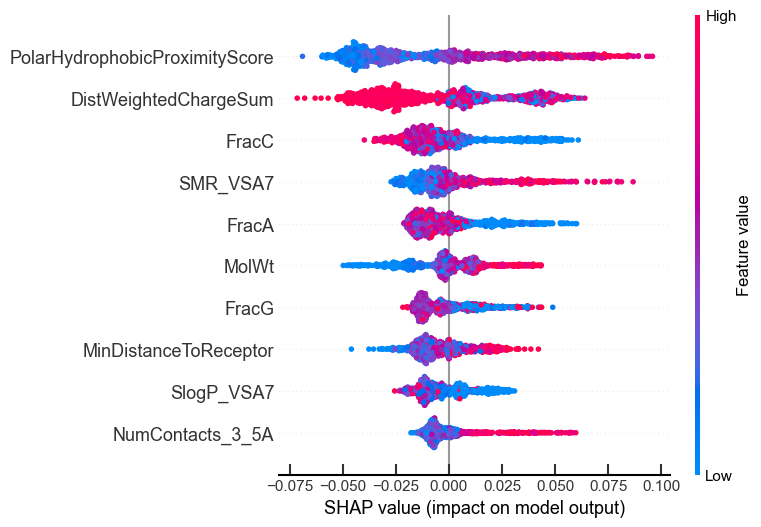

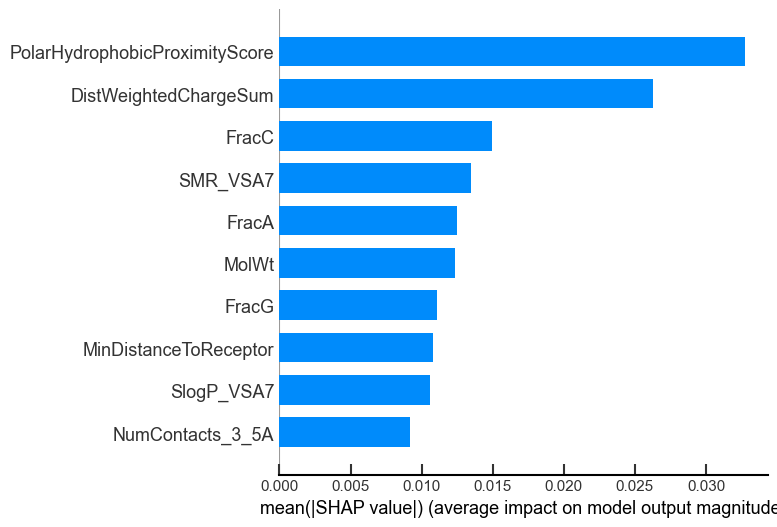

In [9]:
import shap
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# SHAP (Top 10 features only) + print mean(|SHAP|) and mean(SHAP)
# Assumes you already have:
#   - rf_pipeline (fit)
#   - X_train_raw (raw training feature DataFrame used to fit rf_pipeline)
# ============================================================

# Hard-disable any global grid styling (e.g., seaborn whitegrid)
mpl.rcParams["axes.grid"] = False

model = rf_pipeline.named_steps["clf"]

# --- Build the exact post-pipeline feature matrix (what the model actually saw)
X_clean = rf_pipeline.named_steps["clean"].transform(X_train_raw)
X_drop  = rf_pipeline.named_steps["drop_const"].transform(X_clean)
X_final = rf_pipeline.named_steps["corr"].transform(X_drop)

feature_names = rf_pipeline.named_steps["corr"].keep_cols_
X_final_df = pd.DataFrame(X_final, columns=feature_names, index=X_train_raw.index)

# Use the full dataset as background and evaluation
bg = X_final_df
eval_X = X_final_df

print(f"X used for SHAP: {eval_X.shape} (model.n_features_in_={getattr(model, 'n_features_in_', 'NA')})")

# --- TreeExplainer
explainer = shap.TreeExplainer(
    model,
    data=bg,
    feature_perturbation="interventional",
    model_output="probability"
)

try:
    shap_values = explainer.shap_values(eval_X)  # additivity check ON
    print("✅ SHAP additivity check PASSED with model_output='probability'.")
except Exception as e:
    print("⚠️ SHAP additivity check FAILED with model_output='probability'.")
    print("   Error:", e)
    print("   Re-running with check_additivity=False (inputs already validated).")
    shap_values = explainer.shap_values(eval_X, check_additivity=False)

# ------------------------------------------------------------
# Robustly extract class-1 SHAP for binary classification
# shap_values can be:
#   - list: [class0, class1]
#   - ndarray: (n_samples, n_features)  OR  (n_samples, n_features, 2)
# ------------------------------------------------------------
if isinstance(shap_values, list):
    class1_values = shap_values[1]
else:
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3 and shap_values.shape[-1] == 2:
        class1_values = shap_values[:, :, 1]
    else:
        class1_values = shap_values  # already (n_samples, n_features)

# DataFrame of signed SHAP values for class 1
shap_df = pd.DataFrame(class1_values, columns=feature_names, index=eval_X.index)

# --- Top 10 by mean absolute SHAP
mean_abs = shap_df.abs().mean().sort_values(ascending=False)
top10_feats = mean_abs.head(10).index.tolist()

# --- Report both mean(|SHAP|) and mean(SHAP) for those same 10 features
top10_mean_abs = mean_abs.loc[top10_feats]
top10_mean     = shap_df.mean().loc[top10_feats]

summary = pd.DataFrame({
    "mean_abs_shap": top10_mean_abs,
    "mean_shap": top10_mean
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 10 features by mean(|SHAP|), with directionality (mean SHAP):")
for i, (feat, row) in enumerate(summary.iterrows(), 1):
    print(f"{i:2d}. {feat}: mean(|SHAP|)={row['mean_abs_shap']:.6f} | mean(SHAP)={row['mean_shap']:.6f}")

# --- Restrict to Top 10 only (both SHAP matrix and feature matrix)
X_top10 = eval_X[top10_feats]
shap_top10 = shap_df[top10_feats].values  # (n_samples, 10)

# ============================================================
# Plots (Top 10 only) + force grid OFF for axes SHAP creates
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_top10, X_top10, plot_type="dot", show=False)
ax = plt.gca()
ax.grid(False)
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)
ax = plt.gca()
ax.grid(False)
plt.show()

## Figure 4


In [10]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)


# ============================================================
# Load apo-state complex list
# ============================================================
apo_df = pd.read_csv(
    str(DATA_DIR / "naffinity_apo_state.csv"),
    encoding="latin1"
)

apo_folders = set(
    apo_df["Folder"].astype(str)
)

print(f"\nApo-state complexes: {len(apo_folders)}")

# ============================================================
# Restrict test set to apo-state complexes
# ============================================================
test_df = test_df[
    test_df["Folder"].isin(apo_folders)
].copy()

print(
    f"Apo-state test complexes found in NAffinity test set: "
    f"{len(test_df)}"
)

# Rebuild test features/labels
X_test_raw = test_df[feature_cols].reset_index(drop=True)

y_test = (
    test_df["Label"]
    .astype(int)
    .reset_index(drop=True)
)



print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")





# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")

label_map = {
    0: "Weak Binders (≥1 μM)",
    1: "Strong Binders (<1 μM)"
}

y_test_named = y_test.map(label_map)
rf_named = pd.Series(rf_preds).map(label_map)

print(
    "\n"
    + classification_report(
        y_test_named,
        rf_named,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

accuracy_weak = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

accuracy_strong = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print(
    "\n📊 Confusion Matrix "
    "(rows=true, cols=pred; order=[Weak, Strong])"
)
print(cm)

print("\n📊 Per-Class Accuracy:")
print(
    f"  Weak Binders (≥1 μM):   "
    f"{accuracy_weak:.4f}"
)
print(
    f"  Strong Binders (<1 μM): "
    f"{accuracy_strong:.4f}"
)

# ============================================================
# Additional probability diagnostics
# ============================================================
print("\n📈 Probability Summary")
print(
    f"Mean predicted strong-binding probability: "
    f"{rf_probs.mean():.4f}"
)

print(
    f"Predicted strong binders @ threshold "
    f"{OPTIMAL_THRESHOLD}: "
    f"{rf_preds.sum()} / {len(rf_preds)} "
    f"({100 * rf_preds.mean():.1f}%)"
)

# ============================================================
# Counts + class-specific accuracy
# ============================================================

n_total = len(y_test)

n_strong = int((y_test == 1).sum())
n_weak = int((y_test == 0).sum())

correct_strong = int(
    ((y_test == 1) & (rf_preds == 1)).sum()
)

correct_weak = int(
    ((y_test == 0) & (rf_preds == 0)).sum()
)

strong_accuracy = (
    correct_strong / n_strong
    if n_strong > 0 else np.nan
)

weak_accuracy = (
    correct_weak / n_weak
    if n_weak > 0 else np.nan
)

print("\n==============================")
print("APO TEST SET SUMMARY")
print("==============================")

print(f"Total complexes : {n_total}")
print()

print(
    f"Strong binders (<1 μM): "
    f"{correct_strong}/{n_strong} "
    f"({100*strong_accuracy:.1f}%)"
)

print(
    f"Weak binders (≥1 μM): "
    f"{correct_weak}/{n_weak} "
    f"({100*weak_accuracy:.1f}%)"
)

print()

print(
    f"Strong binders total: {n_strong} "
    f"({100*n_strong/n_total:.1f}%)"
)

print(
    f"Weak binders total: {n_weak} "
    f"({100*n_weak/n_total:.1f}%)"
)


Apo-state complexes: 66
Apo-state test complexes found in NAffinity test set: 66
Train rows: 1062 | Test rows: 66 | Raw features: 302

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.8485
  Precision: 0.6667
  Recall   : 0.8235
  F1 Score : 0.7368

                        precision    recall  f1-score   support

Strong Binders (<1 μM)     0.6667    0.8235    0.7368        17
  Weak Binders (≥1 μM)     0.9333    0.8571    0.8936        49

              accuracy                         0.8485        66
             macro avg     0.8000    0.8403    0.8152        66
          weighted avg     0.8646    0.8485    0.8532        66


📊 Confusion Matrix (rows=true, cols=pred; order=[Weak, Strong])
[[42  7]
 [ 3 14]]

📊 Per-Class Accuracy:
  Weak Binders (≥1 μM):   0.8571
  Strong Binders (<1 μM): 0.8235

📈 Probability Summary
Mean predicted strong-binding probability: 0.2842
Predicted strong binders @ threshold 0.38: 21 / 66 (31.8%)

APO TEST SET S

In [11]:
import pandas as pd

apo_table = pd.read_excel(str(DATA_DIR / "NA_complexes_dataset.xlsx"), sheet_name="holo_apo_data")
assert len(apo_table) == 66 and apo_table["Folder"].is_unique
assert set(apo_table["Folder"].str.casefold()) == set(test_df["Folder"].str.casefold())
apo_weak = apo_table[apo_table["TrueClass"].eq("Weak/moderate binder")]
apo_strong = apo_table[apo_table["TrueClass"].eq("Strong binder")]
assert len(apo_weak) == 49 and len(apo_strong) == 17
holo_vals = [100*accuracy_weak, 100*accuracy_strong]
apo_vals = [100*apo_weak["PredictedClass"].eq(apo_weak["TrueClass"]).mean(),
            100*apo_strong["PredictedClass"].eq(apo_strong["TrueClass"]).mean()]
print("Holo weak/strong:", holo_vals, "Apo weak/strong:", apo_vals)


Holo weak/strong: [85.71428571428571, 82.35294117647058] Apo weak/strong: [95.91836734693877, 17.647058823529413]


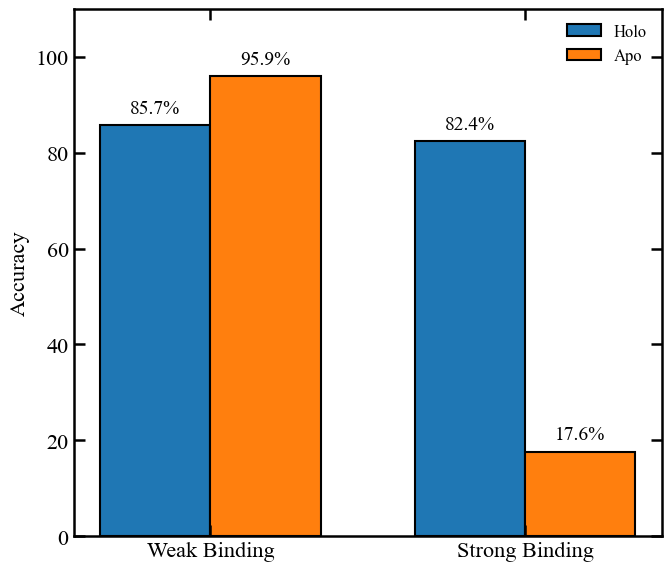

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data (Order Reversed: Weak then Strong)
# =========================
labels = ["Weak Binding", "Strong Binding"]

# Reordering values to match the labels above
# Original Weak: 0.9592 (Holo), 0.9388 (Apo)
# Original Strong: 0.7778 (Holo), 0.4444 (Apo)

x = np.arange(len(labels))
width = 0.35

# =========================
# Origin-style formatting
# =========================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1.8
plt.rcParams['xtick.major.width'] = 1.8
plt.rcParams['ytick.major.width'] = 1.8
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(figsize=(7,6))

bars1 = ax.bar(x - width/2, holo_vals, width,
               label='Holo',
               color='#1f77b4', 
               edgecolor='black',
               linewidth=1.5)

bars2 = ax.bar(x + width/2, apo_vals, width,
               label='Apo',
               color='#ff7f0e', 
               edgecolor='black',
               linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=14)

# Updated Label and Y-axis limits
ax.set_ylabel("Accuracy") # Changed from Per-Class Accuracy
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 110)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_4_apo_holo.png"), dpi=600, bbox_inches="tight")


## Figure 5


In [13]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")



Train rows: 1062 | Test rows: 117 | Raw features: 302

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.8120
  Precision: 0.6792
  Recall   : 0.8780
  F1 Score : 0.7660


In [14]:
# ============================================================
# Predict probabilities
# ============================================================

OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]

# Apply optimized threshold
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# === Extract 4-character PDB ID from folder names (match old behavior)
def extract_pdb_id(folder_name):
    return str(folder_name)[:4].upper()

# Get training and test PDB IDs
train_pdbs = set(train_df["Folder"].apply(extract_pdb_id))
test_pdbs = test_df["Folder"].apply(extract_pdb_id)

# === Build results table (match old format)
results_df = test_df[["Folder", "AffinityValue"]].copy()
results_df["PDB_ID"] = results_df["Folder"].apply(extract_pdb_id)
results_df["TrueLabel"] = y_test.values
results_df["PredictedLabel"] = rf_preds
results_df["PredictedProb_Strong"] = rf_probs
results_df["Correct"] = results_df["PredictedLabel"] == results_df["TrueLabel"]
results_df["PDB_ID_In_Training"] = results_df["PDB_ID"].apply(lambda pdb: pdb in train_pdbs)

# Reorder for clarity (match old column order)
results_df = results_df[
    ["Folder", "PDB_ID", "AffinityValue", "TrueLabel", "PredictedLabel",
     "PredictedProb_Strong", "Correct", "PDB_ID_In_Training"]
]

# === Save to CSV (same name/path as before)
output_path = str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_detailed.csv")
results_df.to_csv(output_path, index=False)
print(f"\n✅ Detailed predictions saved to: {output_path}")



✅ Detailed predictions saved to: results/naffinity_test_predictions_detailed.csv


In [15]:
import os
import pandas as pd
import numpy as np

# === Paths ===
root_dir = str(REPRO_OUTPUT_DIR)
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
pred_path = str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_detailed.csv")

# === Load full dataset and predictions ===
dataset_df = pd.read_csv(dataset_path)

print(f"📂 Loading predictions: {pred_path}")
pred_df = pd.read_csv(pred_path)

# Basic cleanup
dataset_df.replace([np.inf, -np.inf], np.nan, inplace=True)
dataset_df.fillna(0.0, inplace=True)

# === Filter only test set rows from dataset ===
test_feat_df = dataset_df[dataset_df["Split"] == "Stratified"].copy()

# Normalize folder keys for safe merge
test_feat_df["Folder_key"] = test_feat_df["Folder"].astype(str).str.strip().str.lower()
pred_df["Folder_key"] = pred_df["Folder"].astype(str).str.strip().str.lower()

# === Merge: predictions + all test-set features (and any dataset metadata columns)
merged = pred_df.merge(
    test_feat_df,
    on="Folder_key",
    how="left",
    suffixes=("", "_from_dataset")
)

# Keep one canonical Folder column (from predictions) and drop merge key
merged.drop(columns=["Folder_key"], inplace=True)

# === Tag outcome (TP, TN, FP, FN) using prediction columns
def tag_outcome(row):
    t = int(row["TrueLabel"])
    p = int(row["PredictedLabel"])
    if t == 1 and p == 1:
        return "TP"
    elif t == 0 and p == 0:
        return "TN"
    elif t == 1 and p == 0:
        return "FN"
    else:
        return "FP"

merged["Outcome"] = merged.apply(tag_outcome, axis=1)

# === Optional sanity check: how many rows failed to merge
n_missing = merged["Split"].isna().sum() if "Split" in merged.columns else 0
if n_missing > 0:
    print(f"⚠️ Warning: {n_missing} prediction rows did not find matching features in the dataset (Folder mismatch).")

# === Save merged DataFrame
output_path = str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features.csv")
merged.to_csv(output_path, index=False)
print(f"\n✅ Merged prediction + features saved to: {output_path}")


📂 Loading predictions: results/naffinity_test_predictions_detailed.csv

✅ Merged prediction + features saved to: results/naffinity_test_predictions_with_features.csv


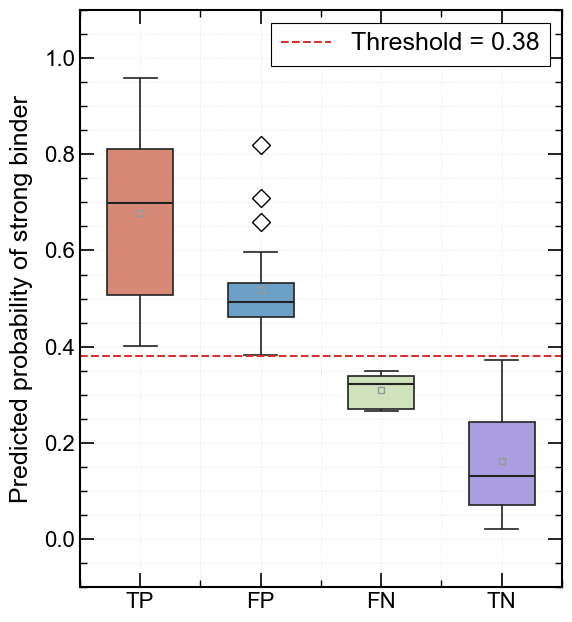

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
import seaborn as sns

# Load data
df = pd.read_csv(
    str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_detailed.csv")
)


# Define outcome group
def get_outcome(row):
    if row["TrueLabel"] == 1 and row["PredictedLabel"] == 1:
        return "TP"
    elif row["TrueLabel"] == 0 and row["PredictedLabel"] == 1:
        return "FP"
    elif row["TrueLabel"] == 1 and row["PredictedLabel"] == 0:
        return "FN"
    else:
        return "TN"


df["Outcome"] = df.apply(get_outcome, axis=1)

# --- Precise Style Adjustments ---

# 1. Vibrant hex colors extracted from your original image
palette = {
    "TP": "#e77f67",  # Vibrant coral/salmon
    "FP": "#5da2d5",  # Classic blue
    "FN": "#cfe8b6",  # Soft lime green
    "TN": "#a393eb",  # Bright pastel purple
}

# 2. Universal styling configuration (using clean Sans-Serif font)
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Arial",
            "Helvetica",
            "DejaVu Sans",
        ],  # Matches original numbers/labels
        "axes.edgecolor": "black",
        "axes.linewidth": 1.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 10,
        "ytick.major.size": 10,
        "xtick.minor.size": 5,
        "ytick.minor.size": 5,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
    }
)

fig, ax = plt.subplots(figsize=(6, 6.5))
ax.set_facecolor("white")

# 3. Plot boxplot with identical whisker & line thickness
sns.boxplot(
    data=df,
    x="Outcome",
    y="PredictedProb_Strong",
    order=["TP", "FP", "FN", "TN"],
    palette=palette,
    width=0.55,
    showmeans=True,
    meanprops={
        "marker": "s",
        "markerfacecolor": "none",
        "markeredgecolor": "#999999",
        "markersize": 4,
    },
    flierprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 9,
    },
    boxprops={"edgecolor": "#222222", "linewidth": 1.2},
    whiskerprops={"color": "#222222", "linewidth": 1.2},
    capprops={"color": "#222222", "linewidth": 1.2},
    medianprops={"color": "#222222", "linewidth": 1.5},
    ax=ax,
)

# 4. Target threshold line (0.38) matching the crimson dash pattern
plt.axhline(
    0.38,
    color="#d63031",
    linestyle="--",
    linewidth=1.5,
    label="Threshold = 0.38",
)

# 5. Fix Ticks: Enable inward ticks everywhere + precise spacing
ax.tick_params(
    bottom=True, top=True, left=True, right=True, which="both", labelsize=16
)

# Replicate the exact 0.05 spacing minor ticks on Y-axis
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))

# Add the minor ticks between groups on the X-axis
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["TP", "FP", "FN", "TN"])
ax.set_xticks([-0.5, 0.5, 1.5, 2.5, 3.5], minor=True)
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.1, 1.1)

# 6. Light dotted grid lines aligned to both major and minor steps
ax.grid(True, which="both", linestyle=":", linewidth=0.6, color="#e0e0e0")
ax.set_axisbelow(True)

# 7. Labels
plt.ylabel("Predicted probability of strong binder", fontsize=18, labelpad=8)
plt.xlabel("")  # Keeping the layout clean like the template

# Change the legend call at the bottom of the script to this:
plt.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=18,
    handlelength=2,
).get_frame().set_linewidth(0.8) # Thins out the border line weight

plt.tight_layout()
plt.show()
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_5_probabilities.png"), dpi=600, bbox_inches="tight")


## Figure 6


In [17]:
import pandas as pd

pred_df = pd.read_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features.csv"))
types = pd.read_csv(str(DATA_DIR / "archived_test_predictions_annotated.csv"))[["Folder", "NA_Type"]]
pred_df["_key"] = pred_df["Folder"].str.strip().str.casefold()
types["_key"] = types["Folder"].str.strip().str.casefold()
assert pred_df["_key"].is_unique and types["_key"].is_unique
merged_df = pred_df.merge(types[["_key", "NA_Type"]], on="_key", how="inner", validate="one_to_one").drop(columns="_key")
assert len(merged_df) == 117 and merged_df["NA_Type"].value_counts().to_dict() == {"RNA": 98, "DNA": 19}
merged_df["Outcome"] = merged_df.apply(lambda r: ("TP" if r.TrueLabel == 1 else "FP") if r.PredictedLabel == 1 else ("FN" if r.TrueLabel == 1 else "TN"), axis=1)
merged_df.to_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features_annotated.csv"), index=False)


In [18]:
import pandas as pd

# === Load annotated test predictions ===
df = pd.read_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features_annotated.csv"))

# === Filter RNA test complexes only ===
rna_df = df[df["NA_Type"] == "RNA"].copy()

n_total = len(rna_df)
n_strong = (rna_df["TrueLabel"] == 1).sum()
n_weak   = (rna_df["TrueLabel"] == 0).sum()

# === Correct predictions by class ===
strong_correct = ((rna_df["TrueLabel"] == 1) & (rna_df["PredictedLabel"] == 1)).sum()
weak_correct   = ((rna_df["TrueLabel"] == 0) & (rna_df["PredictedLabel"] == 0)).sum()

# === Percentages ===
strong_recall = strong_correct / n_strong if n_strong > 0 else 0.0
weak_accuracy = weak_correct / n_weak if n_weak > 0 else 0.0

print("📊 RNA-only Test Set Performance")
print("--------------------------------")
print(f"Total RNA test complexes: {n_total}")
print(f"True strong binders (<1 μM): {n_strong}")
print(f"True weak binders (≥1 μM): {n_weak}")
print()
print(f"Strong binders correctly predicted: {strong_correct}/{n_strong} ({strong_recall:.3f})")
print(f"Weak binders correctly predicted:   {weak_correct}/{n_weak} ({weak_accuracy:.3f})")

📊 RNA-only Test Set Performance
--------------------------------
Total RNA test complexes: 98
True strong binders (<1 μM): 30
True weak binders (≥1 μM): 68

Strong binders correctly predicted: 26/30 (0.867)
Weak binders correctly predicted:   55/68 (0.809)


      Method BindingClass  AccuracyPercent
0    RSAPred         Weak        72.058824
1    RSAPred       Strong        40.000000
2  NAffinity         Weak        80.882353
3  NAffinity       Strong        86.666667


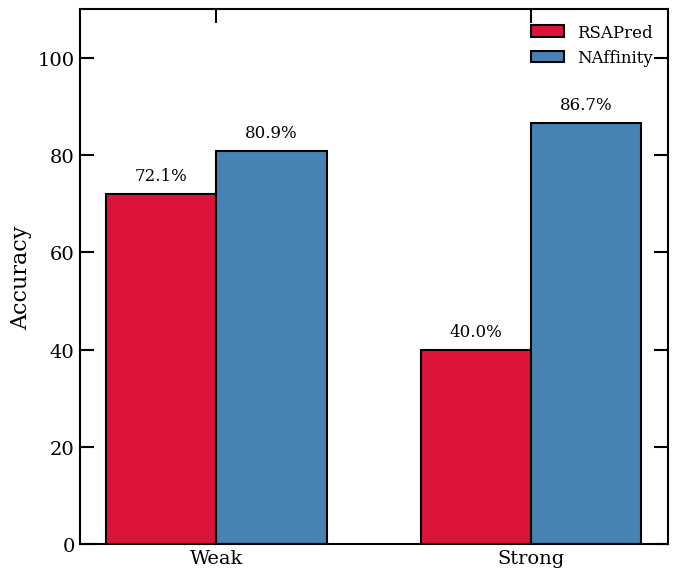

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate class accuracies from the paired RNA evaluation data.
source = pd.read_csv(str(DATA_DIR / "table_s8" / "evaluation.csv"))
assert len(source) == 98
rows = []
for method, col in [("RSAPred", "rsapred_correct"), ("NAffinity", "naffinity_correct")]:
    for cls in ["Weak", "Strong"]:
        subset = source[source["true_label"] == cls]
        rows.append({"Method": method, "BindingClass": cls, "AccuracyPercent": 100*subset[col].astype(bool).mean()})
df = pd.DataFrame(rows)
print(df)

# Origin-like Style Settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

fig, ax = plt.subplots(figsize=(7, 6))

methods = df['Method'].unique()
classes = df['BindingClass'].unique()

x = np.arange(len(classes))
width = 0.35

# Professional colors (Gray for baseline RSAPred, Steel Blue for NAffinity)
colors = ['#DC143C', '#4682B4'] 

for i, method in enumerate(methods):
    # Filter and format data
    subset = df[df['Method'] == method]
    subset = subset.set_index('BindingClass').reindex(classes)
    
    # Plot bars with black edges
    bars = ax.bar(x + (i - 0.5) * width, subset['AccuracyPercent'], width, 
                  label=method, color=colors[i], edgecolor='black', linewidth=1.5)
    
    # Add precise value labels on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=12, color='black')

# Labels and Title
ax.set_ylabel('Accuracy', fontsize=16)
ax.set_title('', fontweight='bold', fontsize=16, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 110) # Room for labels

# Legend without box (a common Origin style feature)
ax.legend(frameon=False, fontsize=12, loc='upper right')

plt.tight_layout()

plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_6_RSAPred_comparison.png"), dpi=600, bbox_inches="tight")


## Figure S1


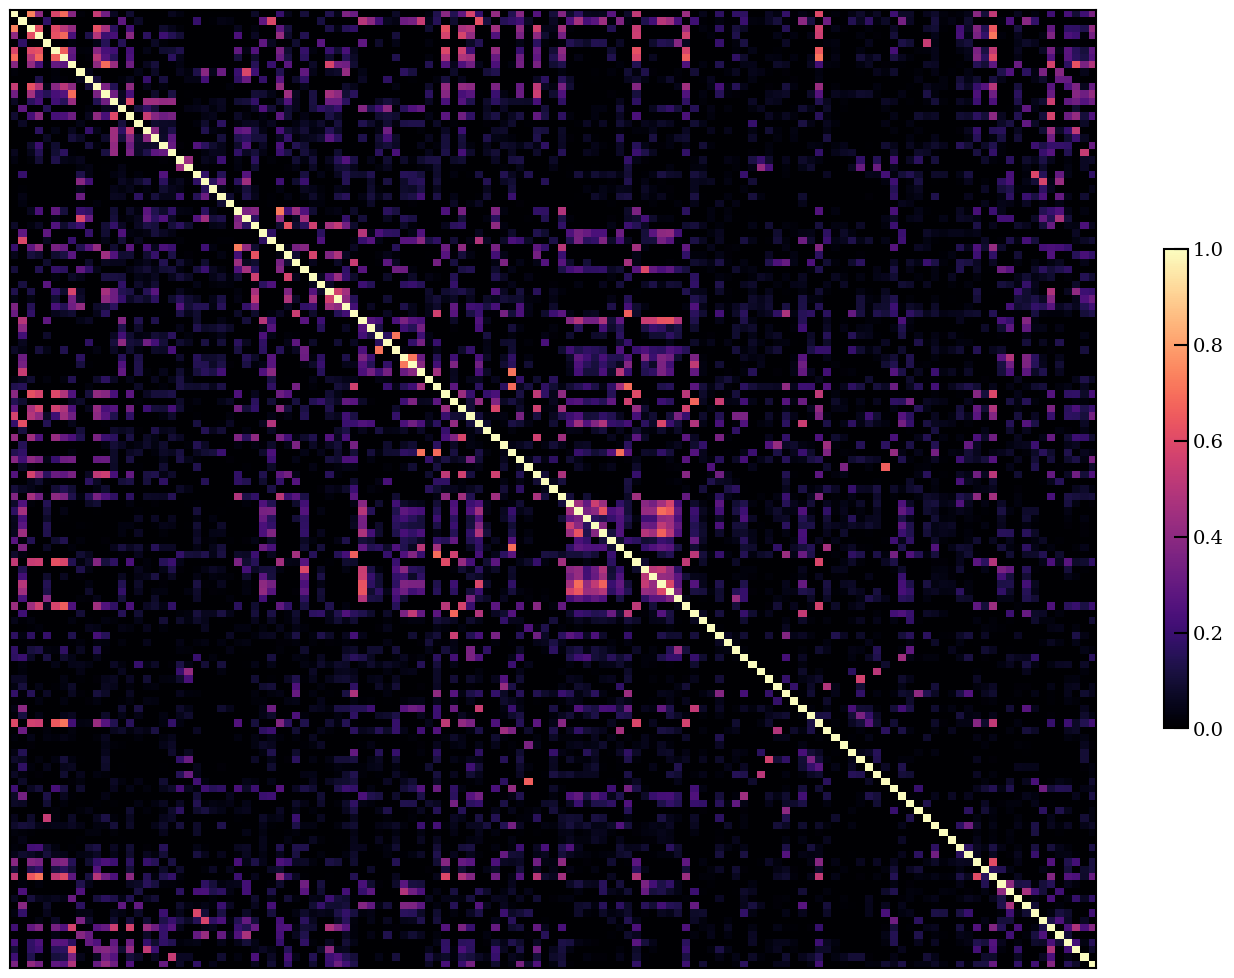

Max |Spearman rho| among final (kept) features: 0.7385304478969138
Mean |Spearman rho| among final (kept) features: 0.1049195898811272
N final features: 131


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already loaded:
df = pd.read_csv(str(DATA_DIR / "naffinity_dataset.csv"))
# and you already have a fit rf_pipeline (with clean/drop_const/corr steps).

# ------------------------------------------------------------
# Match our pipeline: compute correlation on TRAIN only, after
# the same fold-safe preprocessing steps, and using Spearman
# (since that's what your CorrelationFilter uses for dropping).
# No imputation step needed because our pipeline already handles NaN/inf.
# No file output.
# ------------------------------------------------------------

non_feature_cols = ["Label", "ComplexID", "AffinityValue", "Folder", "Split"]

train_df = df[df["Split"] == "Train"].copy()

X_train_raw = train_df.drop(
    columns=[c for c in non_feature_cols if c in train_df.columns],
    errors="ignore"
)

# Apply the same preprocessing steps used by the model pipeline
X_clean = rf_pipeline.named_steps["clean"].transform(X_train_raw)
X_drop  = rf_pipeline.named_steps["drop_const"].transform(X_clean)
X_final = rf_pipeline.named_steps["corr"].transform(X_drop)

feature_names = rf_pipeline.named_steps["corr"].keep_cols_
X_final_df = pd.DataFrame(X_final, columns=feature_names, index=X_train_raw.index)

# Correlation matrix in the model's final feature space
corr_matrix = X_final_df.corr(method="spearman").replace([np.inf, -np.inf], np.nan).fillna(0.0)

# ------------------------------------------------------------
# Plot (matplotlib only)
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))
plt.imshow(
    corr_matrix.values,
    cmap="magma",
    vmin=0,
    vmax=1,
    aspect="auto"
)

plt.title("", fontsize=16)

# Remove feature names from both axes (as in your original)
plt.xticks([])
plt.yticks([])

plt.colorbar(shrink=0.5)
plt.tight_layout()
plt.show()

# Optional quick summary prints
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print("Max |Spearman rho| among final (kept) features:", float(upper.max().max()))
print("Mean |Spearman rho| among final (kept) features:", float(upper.stack().mean()))
print("N final features:", X_final_df.shape[1])

## Figure S2


In [21]:
import pandas as pd

# Coordinates used for the published Figure S2.
tsne_df = pd.read_csv(DATA_DIR / "figure_s2_coordinates.csv")
full_df = pd.read_csv(DATA_DIR / "naffinity_dataset.csv", usecols=["Folder"])

assert len(tsne_df) == 1179
assert tsne_df["Folder"].is_unique
assert set(tsne_df["Folder"]) == set(full_df["Folder"])
assert tsne_df["NA_Type"].isin(["RNA", "DNA"]).all()
assert tsne_df["Split"].value_counts().to_dict() == {"Total": 1062, "Strat": 117}

# Save a working copy for the plotting cell.
tsne_df.to_csv(REPRO_OUTPUT_DIR / "tSNE_with_NA_Type.csv", index=False)


NA_Type
RNA    977
DNA    202
Name: count, dtype: int64


Matched labels for 1179 / 1179 complexes


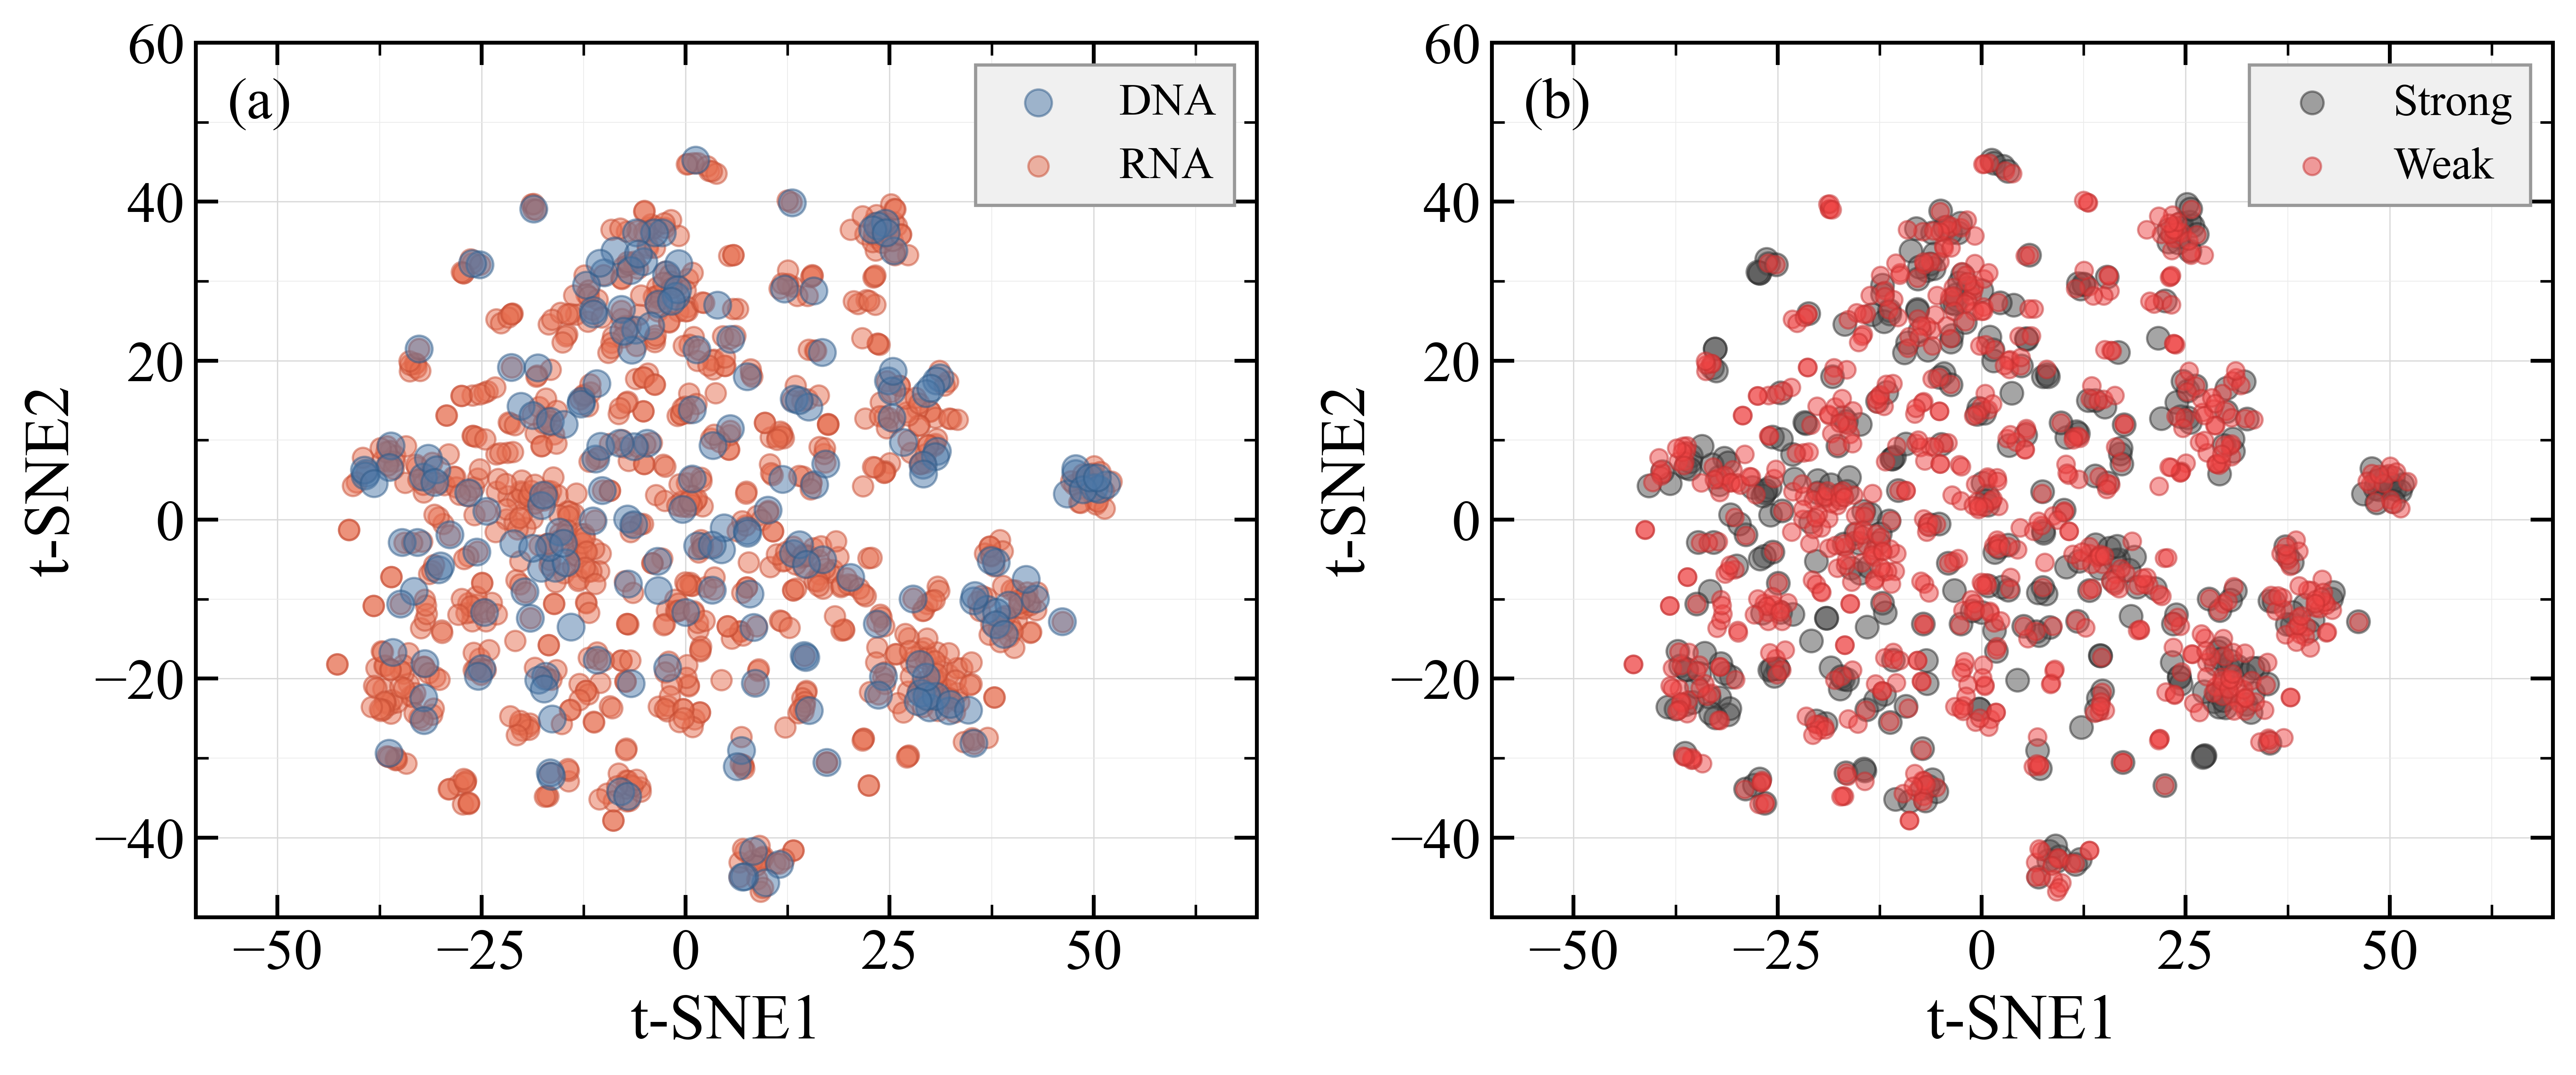

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ============================================================
# Load data
# ============================================================

tsne_df = pd.read_csv(
    str(REPRO_OUTPUT_DIR / "tSNE_with_NA_Type.csv")
)

full_df = pd.read_csv(
    str(DATA_DIR / "naffinity_dataset.csv")
)

# Add binding labels to tSNE coordinates

tsne_df = tsne_df.merge(
    full_df[["Folder", "Label"]],
    on="Folder",
    how="left"
)

print(
    f"Matched labels for "
    f"{tsne_df['Label'].notna().sum()} / {len(tsne_df)} complexes"
)

# ============================================================
# Split data
# ============================================================

dna = tsne_df[tsne_df["NA_Type"] == "DNA"]
rna = tsne_df[tsne_df["NA_Type"] == "RNA"]

strong = tsne_df[tsne_df["Label"] == 1]
weak   = tsne_df[tsne_df["Label"] == 0]

# ============================================================
# Origin-style settings
# ============================================================

plt.rcParams.update({

    "font.family": "Times New Roman",
    "font.size": 18,

    "axes.linewidth": 1.2,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 7,
    "ytick.major.size": 7,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
})

# ============================================================
# Colors
# ============================================================

dna_fill = "#4C78A8"
dna_edge = "#2E5A88"

rna_fill = "#E76F51"
rna_edge = "#C74D33"

strong_fill = "#4D4D4D"
strong_edge = "#2A2A2A"

weak_fill = "#EF4444"
weak_edge = "#C53030"

# ============================================================
# Figure
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(11.5, 5),
    dpi=600
)

# ============================================================
# Panel A
# ============================================================

ax1.scatter(
    rna["tSNE1"],
    rna["tSNE2"],
    s=40,
    c=rna_fill,
    edgecolors=rna_edge,
    linewidths=0.7,
    alpha=0.50,
    label="RNA",
    zorder=2
)

ax1.scatter(
    dna["tSNE1"],
    dna["tSNE2"],
    s=70,
    c=dna_fill,
    edgecolors=dna_edge,
    linewidths=0.7,
    alpha=0.50,
    label="DNA",
    zorder=3
)

handles, labels = ax1.get_legend_handles_labels()

leg1 = ax1.legend(
    [handles[1], handles[0]],
    [labels[1], labels[0]],
    loc="upper right",
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=14
)

leg1.get_frame().set_facecolor("#f0f0f0")
leg1.get_frame().set_alpha(1.0)

ax1.text(
    0.03,
    0.96,
    "(a)",
    transform=ax1.transAxes,
    fontsize=18,
    va="top"
)

# ============================================================
# Panel B
# ============================================================

ax2.scatter(
    strong["tSNE1"],
    strong["tSNE2"],
    s=50,
    c=strong_fill,
    edgecolors=strong_edge,
    linewidths=0.7,
    alpha=0.5,
    label="Strong",
    zorder=2
)

ax2.scatter(
    weak["tSNE1"],
    weak["tSNE2"],
    s=30,
    c=weak_fill,
    edgecolors=weak_edge,
    linewidths=0.7,
    alpha=0.5,
    label="Weak",
    zorder=3
)

leg2 = ax2.legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=14
)

leg2.get_frame().set_facecolor("#f0f0f0")
leg2.get_frame().set_alpha(1.0)

ax2.text(
    0.03,
    0.96,
    "(b)",
    transform=ax2.transAxes,
    fontsize=18,
    va="top"
)

# ============================================================
# Shared formatting
# ============================================================

for ax in [ax1, ax2]:

    ax.grid(
        which="major",
        linestyle="-",
        linewidth=0.4,
        color="0.85"
    )

    ax.grid(
        which="minor",
        linestyle="-",
        linewidth=0.25,
        color="0.92"
    )

    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.set_xlim(-60, 70)
    ax.set_ylim(-50, 60)

    ax.set_xlabel(
        "t-SNE1",
        fontsize=20
    )

    ax.set_ylabel(
        "t-SNE2",
        fontsize=20
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    str(REPRO_OUTPUT_DIR / "Figure_S2_tSNE.tiff"),
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

## Figure S3


In [23]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    PassiveAggressiveClassifier, Perceptron
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")


# ============================================================
# Settings
# ============================================================
csv_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75


# ============================================================
# Load cached dataset
# ============================================================
df = pd.read_csv(csv_path)

# Use only training data
train_df = df[df["Split"] == "Train"].copy()

# Features/labels
y = train_df["Label"].astype(int)

drop_cols = {"Folder", "Split", "Label", "AffinityValue"}
feature_cols = [c for c in train_df.columns if c not in drop_cols]
X_raw = train_df[feature_cols].copy()


# ============================================================
# Fold-specific preprocessing transformers
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)

        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None
        self.drop_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            self.drop_cols_ = []
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]

        self.drop_cols_ = to_drop
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Classifier model zoo
# ============================================================
classifiers = {
    # Baselines
    "ZeroR (Majority Class)": DummyClassifier(strategy="most_frequent"),
    "Random Classifier": DummyClassifier(strategy="uniform", random_state=42),

    # Linear models
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RidgeClassifier": RidgeClassifier(),
    "SGDClassifier": SGDClassifier(),
    "PassiveAggressive": PassiveAggressiveClassifier(),
    "Perceptron": Perceptron(),

    # Probabilistic
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),

    # Instance-based / trees
    "KNeighbors": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "ExtraTree": ExtraTreeClassifier(random_state=42),

    # Ensembles
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),

    # Margin-based
    "SVC": SVC(),
    "LinearSVC": LinearSVC(max_iter=10000),

    # Boosted trees
    "XGBoost": XGBClassifier(random_state=42),
}


# ============================================================
# CV evaluation (fold-specific preprocessing + aligned folds)
# ============================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

print("\n🔬 Running 10-Fold CV on Train Set Only")
print(f"Dataset: {csv_path}")
print(f"Raw features (train): {X_raw.shape[1]}")
print(f"Fold preprocessing: NumericCleaner -> DropConstantColumns -> SpearmanCorr(|r|>{CORR_THRESHOLD})\n")

results = []

for name, clf in classifiers.items():
    print(f"▶️ {name}")
    try:
        pipe = Pipeline([
            ("clean", NumericCleaner(clip_to_float32=True)),
            ("drop_const", DropConstantColumns()),
            ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
            ("clf", clf),
        ])

        out = cross_validate(
            pipe,
            X_raw,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=1,
            error_score="raise",
            return_train_score=False,
        )

        results.append({
            "Model": name,
            "Accuracy (mean)": float(np.mean(out["test_accuracy"])),
            "Accuracy (std)": float(np.std(out["test_accuracy"])),
            "Precision (mean)": float(np.mean(out["test_precision"])),
            "Precision (std)": float(np.std(out["test_precision"])),
            "Recall (mean)": float(np.mean(out["test_recall"])),
            "Recall (std)": float(np.std(out["test_recall"])),
            "F1 (mean)": float(np.mean(out["test_f1"])),
            "F1 (std)": float(np.std(out["test_f1"])),
        })

    except Exception as e:
        print(f"❌ Failed for {name}: {e}")

results_df = pd.DataFrame(results).sort_values("F1 (mean)", ascending=False).reset_index(drop=True)

print("\n🏆 Summary (Sorted by F1 Mean ± Std):")
print(results_df.to_string(index=False))


🔬 Running 10-Fold CV on Train Set Only
Dataset: ../data/naffinity_dataset.csv
Raw features (train): 302
Fold preprocessing: NumericCleaner -> DropConstantColumns -> SpearmanCorr(|r|>0.75)

▶️ ZeroR (Majority Class)
▶️ Random Classifier
▶️ LogisticRegression
▶️ RidgeClassifier
▶️ SGDClassifier
▶️ PassiveAggressive
▶️ Perceptron
▶️ GaussianNB
▶️ BernoulliNB
▶️ KNeighbors
▶️ DecisionTree
▶️ ExtraTree
▶️ RandomForest
▶️ GradientBoosting
▶️ AdaBoost
▶️ Bagging
▶️ SVC
▶️ LinearSVC
▶️ XGBoost

🏆 Summary (Sorted by F1 Mean ± Std):
                 Model  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1 (mean)  F1 (std)
          RandomForest         0.796667        0.026895          0.772233         0.066473       0.557540      0.078626   0.642677  0.057468
      GradientBoosting         0.774035        0.030777          0.711839         0.074116       0.548889      0.084417   0.614330  0.063123
               XGBoost         0.770270        

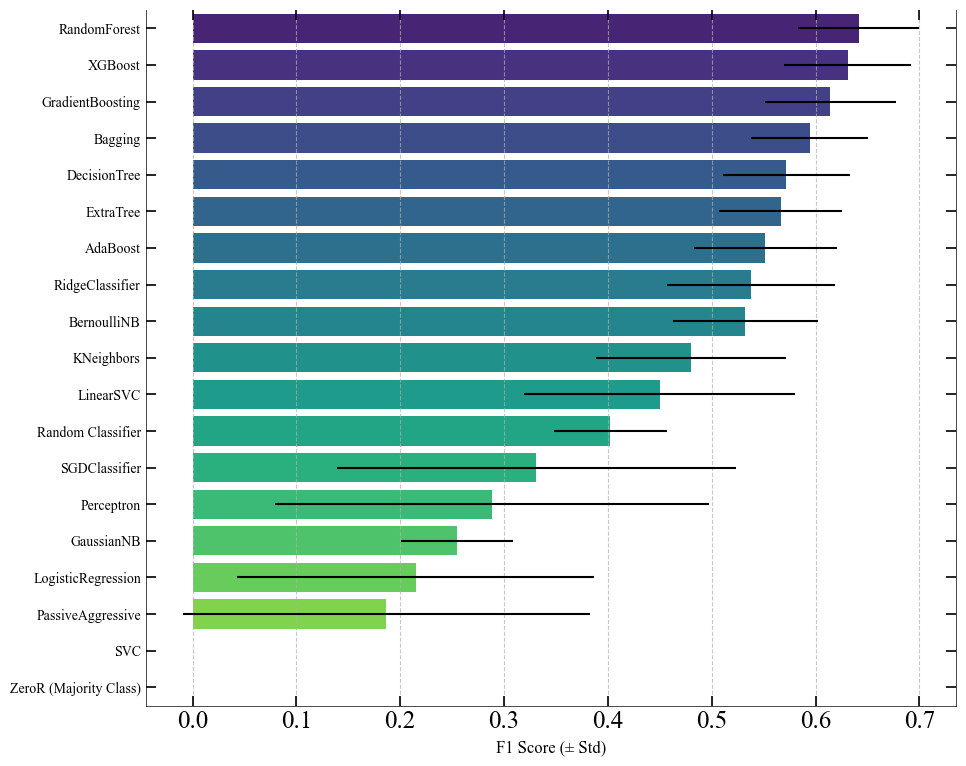

<Figure size 640x480 with 0 Axes>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(str(DATA_DIR / "archived_model_zoo_results.csv"))[["Model", "F1 (mean)", "F1 (std)"]].rename(columns={"F1 (mean)": "F1 Mean", "F1 (std)": "F1 Std"}).copy()
df = df.sort_values("F1 Mean", ascending=False).reset_index(drop=True)

# === Plot ===
plt.figure(figsize=(10, 8))
y_pos = np.arange(len(df))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(df)))

plt.barh(
    y_pos,
    df["F1 Mean"],
    xerr=df["F1 Std"],
    color=colors
)

plt.yticks(y_pos, df["Model"], fontsize=10)
plt.xlabel("F1 Score (± Std)", fontsize=12)
plt.title("", fontsize=13)

# Highest-performing model at top
plt.gca().invert_yaxis()
plt.ylim(len(df) - 0.5, -0.5)

# Styling
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.grid(False, axis="y")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_linewidth(0.5)
plt.gca().spines["left"].set_linewidth(0.5)
plt.gca().spines["bottom"].set_linewidth(0.5)

plt.tight_layout()
plt.show()
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_S3_model_zoo.png"), dpi=600, bbox_inches="tight")


## Table S1


In [25]:
import pandas as pd
from pathlib import Path
table_s1 = pd.read_csv(str(DATA_DIR / "archived_model_zoo_results.csv"))
assert len(table_s1) == 19 and table_s1["Model"].is_unique
table_s1.to_csv(str(REPRO_OUTPUT_DIR / "Table_S1_model_zoo.csv"), index=False)
print(table_s1.to_string(index=False))


                 Model  Accuracy (mean)  Accuracy (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  F1 (mean)  F1 (std)
          RandomForest         0.795724        0.027515          0.769233         0.068067       0.557540      0.078626   0.641660  0.058121
               XGBoost         0.778734        0.025591          0.710060         0.066721       0.580238      0.100286   0.630792  0.060829
      GradientBoosting         0.774035        0.030777          0.711839         0.074116       0.548889      0.084417   0.614330  0.063123
               Bagging         0.764601        0.032565          0.700314         0.077464       0.523095      0.070875   0.594347  0.056604
          DecisionTree         0.719441        0.041948          0.581641         0.068748       0.565873      0.068985   0.571918  0.061284
             ExtraTree         0.715588        0.036539          0.573337         0.059327       0.562460      0.072190   0.566320  0.059096
             

## Table S2


In [26]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
csv_path = str(DATA_DIR / "naffinity_dataset.csv")

CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
N_SPLITS = 10
RANDOM_STATE = 42

# Choose which metric defines "best" hyperparameters:
PRIMARY_METRIC = "f1"  # "accuracy", "precision", "recall", "f1"

# ============================================================
# Load dataset (Train split only)
# ============================================================
df = pd.read_csv(csv_path)
train_df = df[df["Split"] == "Train"].copy()

y = train_df["Label"].astype(int)

drop_cols = {"Folder", "Split", "Label", "AffinityValue"}
feature_cols = [c for c in train_df.columns if c not in drop_cols]
X_raw = train_df[feature_cols].copy()

print(f"\nDataset: {csv_path}")
print(f"Train rows: {X_raw.shape[0]}")
print(f"Raw feature columns: {X_raw.shape[1]}")
print(f"CV: StratifiedKFold(n_splits={N_SPLITS}, shuffle=True, random_state={RANDOM_STATE})")
print(f"Fold preprocessing: NumericCleaner -> DropConstantColumns -> {CORR_METHOD}Corr(|r|>{CORR_THRESHOLD})")
print(f"Selecting best params by: mean_test_{PRIMARY_METRIC}\n")

# ============================================================
# Fold-specific preprocessing transformers
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)

        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)

# ============================================================
# Pipeline
# ============================================================
pipe = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

# ============================================================
# Hyperparameter grid (as requested)
# ============================================================
param_grid = {
    "model__n_estimators": [100, 200, 300, 400, 500, 600, 700, 900, 1000],
    "model__max_depth": [
        10,
        20,
        40,
        None
    ],
    "model__min_samples_split": [
        2,
        5
    ],
    "model__min_samples_leaf": [
        1,
        2
    ],
    "model__bootstrap": [
        True,
        False
    ],
    "model__class_weight": [
        None,
        "balanced",
        "balanced_subsample"
    ]
}

# ============================================================
# Multi-metric scoring (as requested)
# ============================================================
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

from sklearn.base import clone
from sklearn.model_selection import cross_validate
from pathlib import Path

SELECTED_PARAMS = {
    "model__n_estimators": 300,
    "model__max_depth": 10,
    "model__min_samples_split": 5,
    "model__min_samples_leaf": 2,
    "model__bootstrap": False,
    "model__class_weight": "balanced",
}
selected = clone(pipe).set_params(**SELECTED_PARAMS)
score = cross_validate(selected, X_raw, y, cv=cv, scoring=scorers, n_jobs=1, error_score="raise")
mean_f1 = float(np.mean(score["test_f1"]))
std_f1 = float(np.std(score["test_f1"]))
rows = []
for name, options in param_grid.items():
    rows.append({"Parameter": name[len("model__"):],
                 "Search values": ", ".join(str(value) for value in options),
                 "Selected value": str(SELECTED_PARAMS[name])})
table_s2 = pd.DataFrame(rows)
table_s2["Selected configuration CV F1 (mean ± SD)"] = ""
table_s2.loc[0,"Selected configuration CV F1 (mean ± SD)"] = f"{mean_f1:.3f} ± {std_f1:.3f}"
table_s2.to_csv(str(REPRO_OUTPUT_DIR / "Table_S2_hyperparameters.csv"),index=False)
print(table_s2.to_string(index=False))
print("Selected configuration ten-fold CV F1:",round(mean_f1,3),"±",round(std_f1,3))

# Set this to True only when independently repeating the complete 8,640-fit grid search.
RUN_FULL_GRID_SEARCH = False
if RUN_FULL_GRID_SEARCH:
    grid = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorers, refit=False,
                        cv=cv, n_jobs=-1, return_train_score=False, error_score="raise")
    grid.fit(X_raw,y)
    best_idx = int(np.argmax(grid.cv_results_["mean_test_f1"]))
    print("Full-grid best:",grid.cv_results_["params"][best_idx])



Dataset: ../data/naffinity_dataset.csv
Train rows: 1062
Raw feature columns: 302
CV: StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
Fold preprocessing: NumericCleaner -> DropConstantColumns -> spearmanCorr(|r|>0.75)
Selecting best params by: mean_test_f1

        Parameter                                Search values Selected value Selected configuration CV F1 (mean ± SD)
     n_estimators 100, 200, 300, 400, 500, 600, 700, 900, 1000            300                            0.677 ± 0.073
        max_depth                             10, 20, 40, None             10                                         
min_samples_split                                         2, 5              5                                         
 min_samples_leaf                                         1, 2              2                                         
        bootstrap                                  True, False          False                                         
     class_weigh

## Figure S4


Optimal threshold: 0.38
F1 score: 0.6994


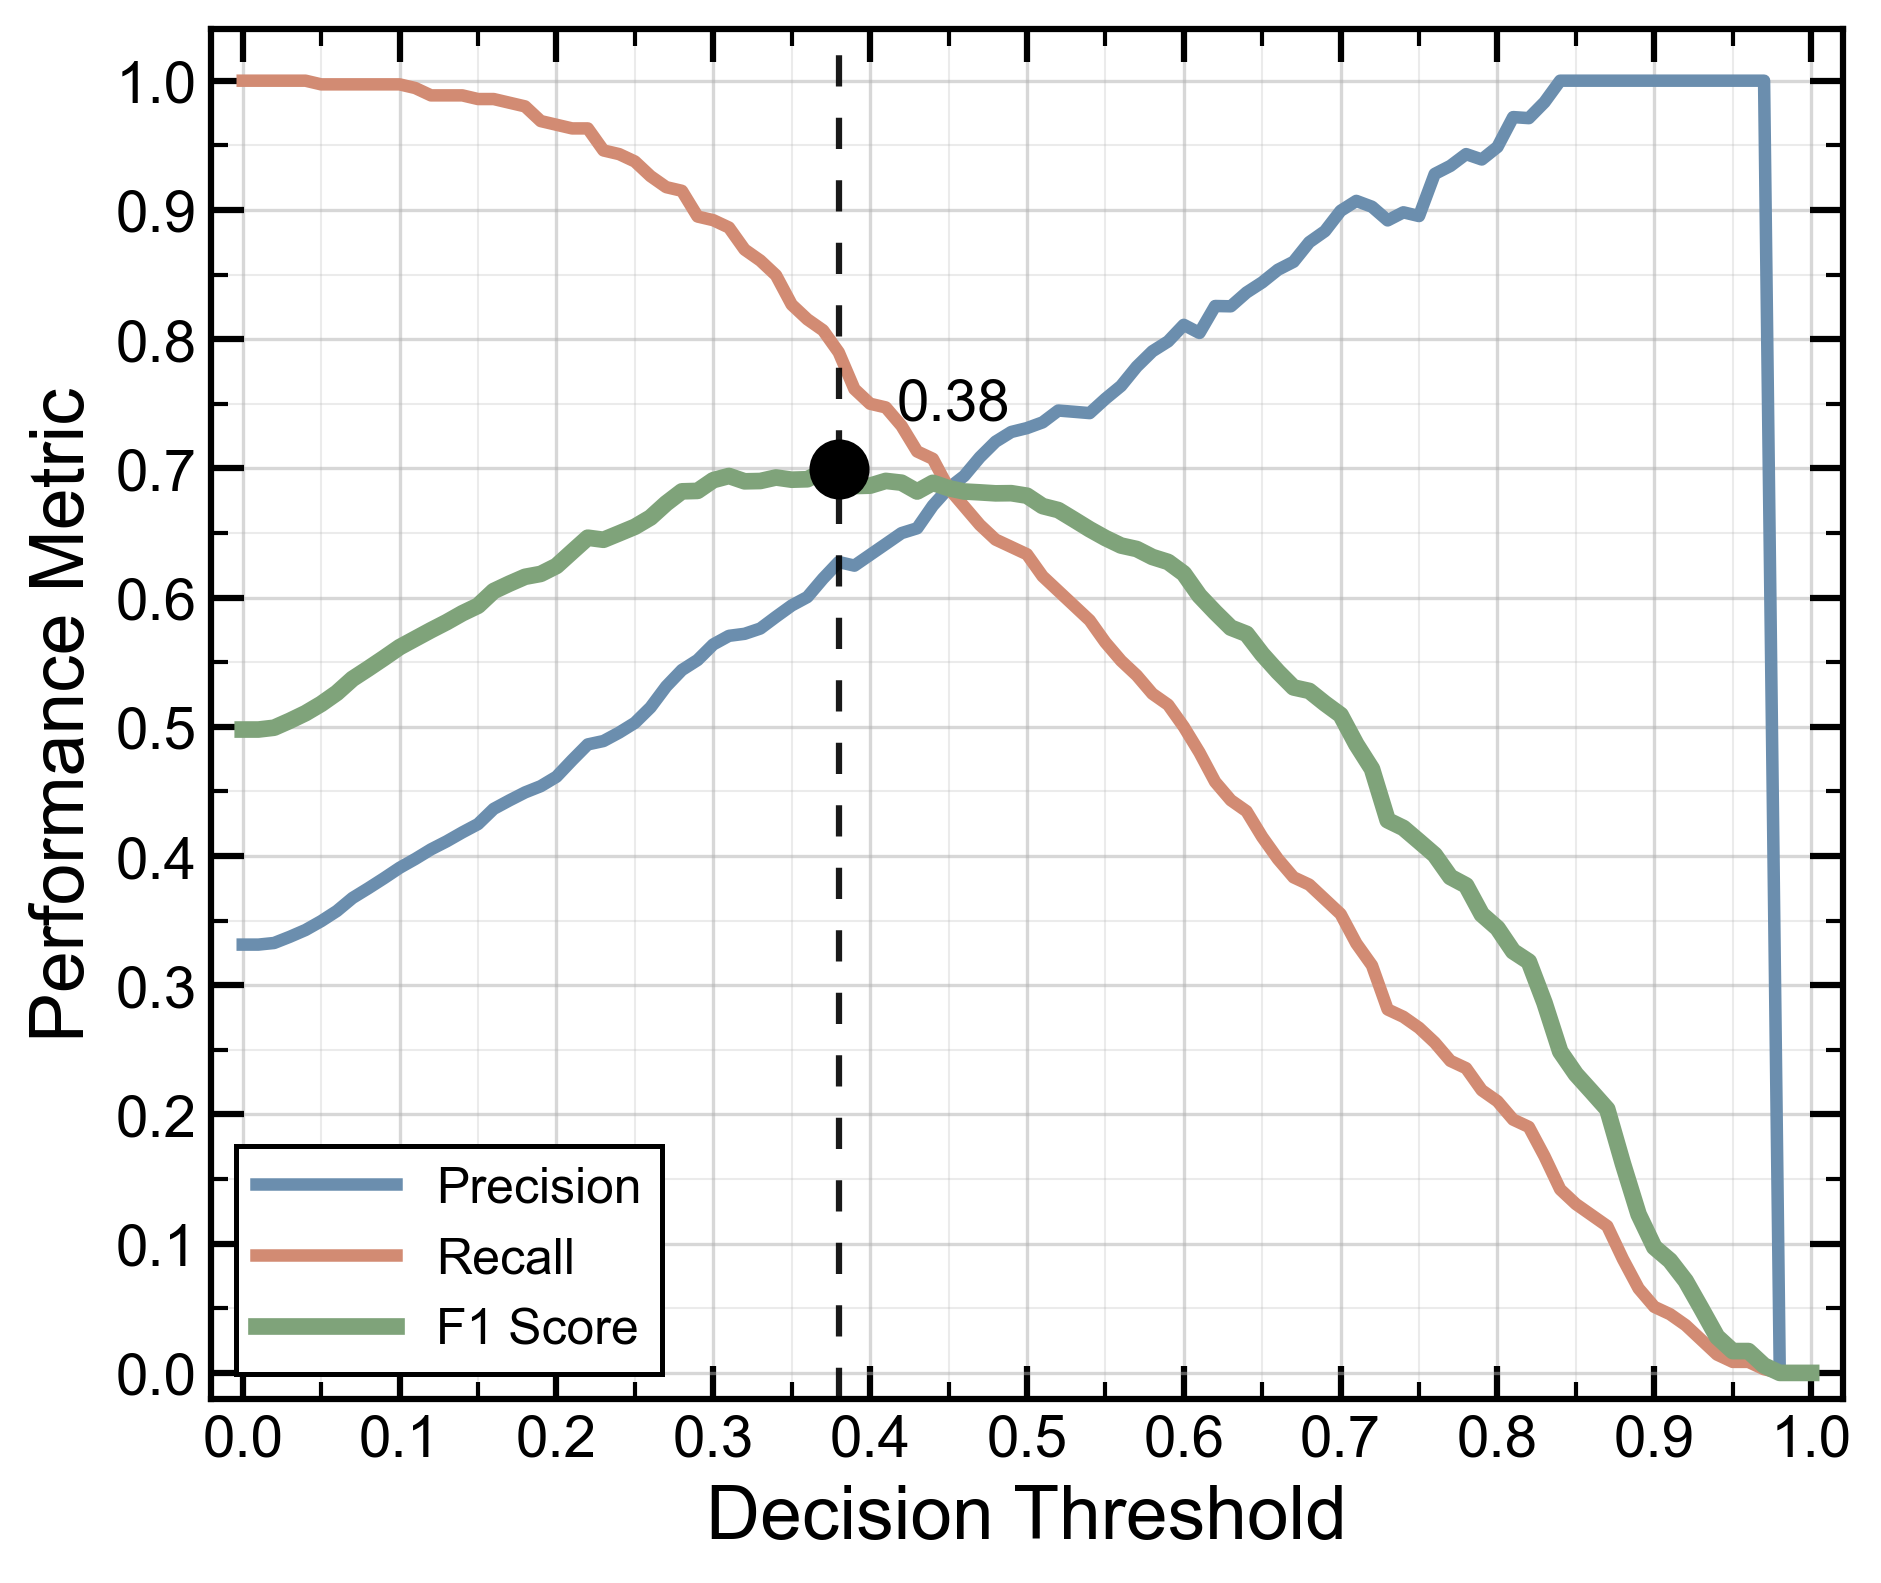

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Threshold sweep used for the published Figure S4.
results_df = pd.read_csv(DATA_DIR / "figure_s4_threshold_sweep.csv")
assert len(results_df) == 101
assert results_df["Threshold"].is_monotonic_increasing

best_row = results_df.loc[results_df["F1"].idxmax()]
assert np.isclose(best_row["Threshold"], 0.38)

print(f"Optimal threshold: {best_row['Threshold']:.2f}")
print(f"F1 score: {best_row['F1']:.4f}")

results_df.to_csv(REPRO_OUTPUT_DIR / "naffinity_threshold_sweep.csv", index=False)

from matplotlib.ticker import AutoMinorLocator

# ============================================================
# Origin-style Plot
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 14,
    "axes.linewidth": 1.5,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 8,
    "xtick.major.width": 1.5,
    "ytick.major.size": 8,
    "ytick.major.width": 1.5,

    "xtick.minor.size": 4,
    "xtick.minor.width": 1.0,
    "ytick.minor.size": 4,
    "ytick.minor.width": 1.0,

    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.fontsize": 12,
})

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

# Muted Origin-style palette
precision_color = "#6B8EAE"   # dusty blue
recall_color    = "#D28B73"   # muted terracotta
f1_color        = "#7FA37A"   # sage green

# ============================================================
# Curves
# ============================================================

ax.plot(
    results_df["Threshold"],
    results_df["Precision"],
    color=precision_color,
    linewidth=3.0,
    label="Precision"
)

ax.plot(
    results_df["Threshold"],
    results_df["Recall"],
    color=recall_color,
    linewidth=3.0,
    label="Recall"
)

ax.plot(
    results_df["Threshold"],
    results_df["F1"],
    color=f1_color,
    linewidth=4.0,
    label="F1 Score"
)

# ============================================================
# Best threshold marker
# ============================================================

ax.axvline(
    best_row["Threshold"],
    color="black",
    linestyle=(0, (5, 5)),
    linewidth=1.5,
    alpha=0.9
)

ax.scatter(
    best_row["Threshold"],
    best_row["F1"],
    s=180,
    color="black",
    zorder=10
)

ax.annotate(
    f"{best_row['Threshold']:.2f}",
    xy=(best_row["Threshold"], best_row["F1"]),
    xytext=(14, 12),
    textcoords="offset points",
    fontsize=14
)

# ============================================================
# Axes
# ============================================================

ax.set_xlabel(
    "Decision Threshold",
    fontsize=18
)

ax.set_ylabel(
    "Performance Metric",
    fontsize=18
)

# Fix clipping around origin
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.04)

# Major ticks
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_yticks(np.arange(0, 1.01, 0.1))

# Minor ticks (Origin-style)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Grid
ax.set_axisbelow(True)

ax.grid(
    True,
    which="major",
    linewidth=0.8,
    alpha=0.5
)

ax.grid(
    True,
    which="minor",
    linewidth=0.5,
    alpha=0.25
)

# ============================================================
# Legend
# ============================================================

leg = ax.legend(
    loc="lower left",
    handlelength=2.8
)

leg.get_frame().set_linewidth(1.2)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    str(REPRO_OUTPUT_DIR / "Figure_S4_threshold_sweep.tiff"),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## Figure S5


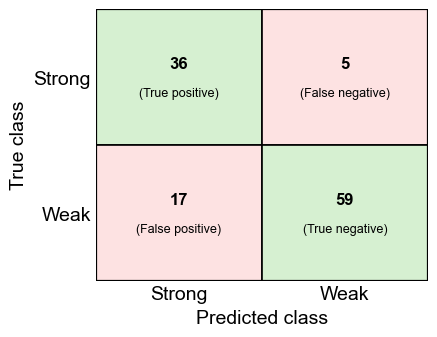

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt

# Confusion matrix values
TP, FN = 36, 5
FP, TN = 17, 59

fig, ax = plt.subplots(figsize=(4.6, 3.6))

# Define colors
green = "#d6f0d1"
red   = "#fde2e2"

# Draw cells: (x, y, value, label, color)
cells = [
    (0, 1, TP, "True positive", green),
    (1, 1, FN, "False negative", red),
    (0, 0, FP, "False positive", red),
    (1, 0, TN, "True negative", green),
]

for x, y, value, label, color in cells:
    ax.add_patch(
        plt.Rectangle(
            (x, y), 1, 1,
            facecolor=color,
            edgecolor="black",
            linewidth=1.2
        )
    )
    ax.text(x + 0.5, y + 0.60, f"{value}",
            ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(x + 0.5, y + 0.38, f"({label})",
            ha="center", va="center",
            fontsize=9)

# Axes limits
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)

# Tick labels
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Strong", "Weak"])
ax.set_yticklabels(["Weak", "Strong"])

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

# Remove tick marks
ax.tick_params(length=0)

# Draw outer border explicitly
ax.add_patch(
    plt.Rectangle(
        (0, 0), 2, 2,
        fill=False,
        edgecolor="black",
        linewidth=1.6
    )
)

# Keep axes frame off (outer box handled manually)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Optional export
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_S5_confusion_matrix.pdf"), bbox_inches="tight")

## Figure S6


In [29]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

from sklearn.model_selection import StratifiedGroupKFold
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)
# ============================================================
# Receptor groups (PDB-level)
# ============================================================
df["PDB"] = (
    df["Folder"]
    .astype(str)
    .str[:4]
    .str.upper()
)

print(
    f"Unique receptor groups: "
    f"{df['PDB'].nunique()}"
)

print(
    "\nTop receptor counts:\n"
)

print(
    df["PDB"]
    .value_counts()
    .head(20)
)
print("\nLargest receptor groups:")

print(

    df["PDB"]

    .value_counts()

    .head(10)

)
drop_cols = [
    "AffinityValue",
    "Label",
    "Folder",
    "Split",
    "PDB"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
]

X = df[feature_cols].reset_index(drop=True)

y = (
    df["Label"]
    .astype(int)
    .reset_index(drop=True)
)

groups = (
    df["PDB"]
    .reset_index(drop=True)
)
print(f"Total rows: {len(df)}")
print(f"Raw features: {len(feature_cols)}")
# ============================================================
# Receptor-aware cross validation
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = []

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(
        X,
        y,
        groups
    ),
    start=1
):

    print(
        f"\n===================="
        f"\nFold {fold}"
        f"\n===================="
    )

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]
    print(
        f"Train samples: {len(train_idx)} | "
        f"Test samples: {len(test_idx)}"
    )

    print(
        f"Train receptors: {groups.iloc[train_idx].nunique()} | "
        f"Test receptors: {groups.iloc[test_idx].nunique()}"
    )
    rf_pipeline = Pipeline([
        ("clean", NumericCleaner()),
        ("drop_const", DropConstantColumns()),
        (
            "corr",
            CorrelationFilter(
                threshold=CORR_THRESHOLD,
                method=CORR_METHOD
            )
        ),
        (
            "clf",
            RandomForestClassifier(
                **RF_PARAMS
            )
        ),
    ])

    rf_pipeline.fit(
        X_train,
        y_train
    )

    probs = (
        rf_pipeline
        .predict_proba(X_test)[:, 1]
    )

    preds = (
        probs >= 0.38
    ).astype(int)

    fold_metrics = {
        "accuracy":
            accuracy_score(
                y_test,
                preds
            ),

        "precision":
            precision_score(
                y_test,
                preds,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_test,
                preds,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_test,
                preds
            ),

        "mcc":
            matthews_corrcoef(
                y_test,
                preds
            ),

        "auroc":
            roc_auc_score(
                y_test,
                probs
            ),

        "auprc":
            average_precision_score(
                y_test,
                probs
            )
    }

    metrics.append(
        fold_metrics
    )

    print(
        pd.Series(
            fold_metrics
        )
        .round(4)
    )
# ============================================================
# Summary
# ============================================================

results = pd.DataFrame(metrics)

print(
    "\n===================="
    "\nPDB-Level Group CV"
    "\n===================="
)

print("\nMean Metrics:")
print(
    results.mean().round(4)
)

print("\nStandard Deviations:")
print(
    results.std().round(4)
)

Unique receptor groups: 438

Top receptor counts:

PDB
1PBR    236
1UUI     65
8D28     39
5XI1     35
7XD5     35
7SXP     20
7TZS     19
1EVV     19
3TZR     17
3S4P     14
6VA2     13
6UBU     13
4U8A     13
6WZR     11
1AJU     11
7WGW     11
2JWQ     11
4ERJ     10
1DL8     10
4LVZ      9
Name: count, dtype: int64

Largest receptor groups:
PDB
1PBR    236
1UUI     65
8D28     39
5XI1     35
7XD5     35
7SXP     20
7TZS     19
1EVV     19
3TZR     17
3S4P     14
Name: count, dtype: int64
Total rows: 1179
Raw features: 302

Fold 1
Train samples: 1027 | Test samples: 152
Train receptors: 398 | Test receptors: 40
accuracy     0.7961
precision    0.4808
recall       0.8621
f1           0.6173
mcc          0.5322
auroc        0.8809
auprc        0.6556
dtype: float64

Fold 2
Train samples: 993 | Test samples: 186
Train receptors: 340 | Test receptors: 98
accuracy     0.7634
precision    0.6962
recall       0.7333
f1           0.7143
mcc          0.5132
auroc        0.8501
auprc        0

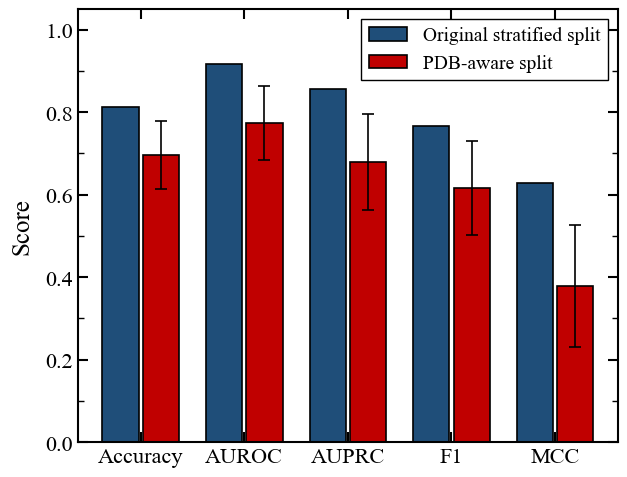

<Figure size 640x480 with 0 Axes>

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Set global font to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score, matthews_corrcoef
metrics = ["Accuracy", "AUROC", "AUPRC", "F1", "MCC"]
full = pd.read_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_detailed.csv"))
y_true = full["TrueLabel"].astype(int).to_numpy()
y_pred = full["PredictedLabel"].astype(int).to_numpy()
y_prob = full["PredictedProb_Strong"].astype(float).to_numpy()
original = [accuracy_score(y_true,y_pred), roc_auc_score(y_true,y_prob), average_precision_score(y_true,y_prob), f1_score(y_true,y_pred), matthews_corrcoef(y_true,y_pred)]
receptor_mean = [results[c].mean() for c in ["accuracy","auroc","auprc","f1","mcc"]]
receptor_std = [results[c].std() for c in ["accuracy","auroc","auprc","f1","mcc"]]


x = np.arange(len(metrics))
width = 0.35  # Slightly narrowed to add clean spacing between groups

# Origin graphs often use a slightly boxier aspect ratio
plt.figure(figsize=(6.5, 5))

# 1. Plot Bars with sharp black edges (Origin Default)
plt.bar(
    x - width/2 - 0.02, # Slight offset to separate the bars cleanly
    original,
    width,
    color='#1F4E79',     # Deep classic steel blue
    edgecolor='black',
    linewidth=1.2,
    label="Original stratified split"
)

plt.bar(
    x + width/2 + 0.02,
    receptor_mean,
    width,
    yerr=receptor_std,
    color='#C00000',     # Sharp Origin-style dark red
    edgecolor='black',
    linewidth=1.2,
    # Custom error bar styling matching Origin's neat rendering
    error_kw=dict(ecolor='black', lw=1.2, capsize=4, capthick=1.2),
    label="PDB-aware split"
)

# Labels & Fonts
plt.ylabel("Score", fontsize=18, labelpad=8)
plt.xticks(x, metrics, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 1.05) # Give a tiny bit of breathing room at the top line

# 2. Origin Frame & Ticks Configuration
ax = plt.gca()

# Thicken the outer border frame
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Force major ticks inward on all 4 sides
ax.tick_params(direction='in', top=True, right=True, width=1.5, length=7, labelsize=16)

# Add inward-facing minor ticks on the Y-axis 
ax.yaxis.set_minor_locator(AutoMinorLocator(2)) # Adds 1 minor tick between major ticks
ax.tick_params(which='minor', direction='in', top=True, right=True, width=1.0, length=4)

# 3. Origin-Style Clean Legend Box
plt.legend(
    fontsize=14, 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='black', 
    framealpha=1
)

plt.tight_layout()
plt.show()
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_S6_receptor_aware.png"), dpi=600, bbox_inches="tight")


## Table S3


In [31]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()
# ============================================================
# Experimental-only training set
# ============================================================

train_df_exp_only = train_df[
    train_df["Folder"]
    .astype(str)
    .str.match(r"^[A-Za-z0-9]{4}$")
].copy()

print(
    f"Original training complexes: "
    f"{len(train_df)}"
)

print(
    f"Experimental-only training complexes: "
    f"{len(train_df_exp_only)}"
)
# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df_exp_only[
    feature_cols
].reset_index(drop=True)

y_train = (
    train_df_exp_only["Label"]
    .astype(int)
    .reset_index(drop=True)
)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(
    f"Train rows: {len(train_df_exp_only)} | "
    f"Test rows: {len(test_df)} | "
    f"Raw features: {len(feature_cols)}"
)

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
auroc = roc_auc_score(y_test, rf_probs)
auprc = average_precision_score(y_test, rf_probs)

print(f"  AUROC   : {auroc:.4f}")
print(f"  AUPRC   : {auprc:.4f}")

print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")



Original training complexes: 1062
Experimental-only training complexes: 379
Train rows: 379 | Test rows: 117 | Raw features: 302
  AUROC   : 0.8161
  AUPRC   : 0.7439

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.6154
  Precision: 0.4750
  Recall   : 0.9268
  F1 Score : 0.6281


## Table S4


In [32]:
label_map = {
    0: "Weak Binders (≥1 μM)",
    1: "Strong Binders (<1 μM)"
}

y_test_named = y_test.map(label_map)
rf_named = pd.Series(rf_preds).map(label_map)

print(
    "\n"
    + classification_report(
        y_test_named,
        rf_named,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

accuracy_weak = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

accuracy_strong = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print(
    "\n📊 Confusion Matrix "
    "(rows=true, cols=pred; order=[Weak, Strong])"
)
print(cm)

print("\n📊 Per-Class Accuracy:")
print(
    f"  Weak Binders (≥1 μM):   "
    f"{accuracy_weak:.4f}"
)
print(
    f"  Strong Binders (<1 μM): "
    f"{accuracy_strong:.4f}"
)

# ============================================================
# Additional probability diagnostics
# ============================================================
print("\n📈 Probability Summary")
print(
    f"Mean predicted strong-binding probability: "
    f"{rf_probs.mean():.4f}"
)

print(
    f"Predicted strong binders @ threshold "
    f"{OPTIMAL_THRESHOLD}: "
    f"{rf_preds.sum()} / {len(rf_preds)} "
    f"({100 * rf_preds.mean():.1f}%)"
)


                        precision    recall  f1-score   support

Strong Binders (<1 μM)     0.4750    0.9268    0.6281        41
  Weak Binders (≥1 μM)     0.9189    0.4474    0.6018        76

              accuracy                         0.6154       117
             macro avg     0.6970    0.6871    0.6149       117
          weighted avg     0.7634    0.6154    0.6110       117


📊 Confusion Matrix (rows=true, cols=pred; order=[Weak, Strong])
[[34 42]
 [ 3 38]]

📊 Per-Class Accuracy:
  Weak Binders (≥1 μM):   0.4474
  Strong Binders (<1 μM): 0.9268

📈 Probability Summary
Mean predicted strong-binding probability: 0.4789
Predicted strong binders @ threshold 0.38: 80 / 117 (68.4%)


## Table S5


In [33]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
all_features = [
    c for c in df.columns
    if c not in drop_cols
]
# ============================================================
# Get retained features from FULL model
# ============================================================

X_train_full = train_df[all_features]
y_train = train_df["Label"].astype(int)

full_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(
        threshold=CORR_THRESHOLD,
        method=CORR_METHOD
    )),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

full_pipeline.fit(X_train_full, y_train)

RETAINED_FEATURES = (
    full_pipeline.named_steps["corr"]
    .keep_cols_
)

print(
    f"\nRetained features after filtering: "
    f"{len(RETAINED_FEATURES)}"
)
# ============================================================
# Feature groups
# ============================================================

RECEPTOR_FEATURES = [
    "NumBindingSiteAtoms",
    "NumWaterMolecules",
    "IsHelixSite",
    "IsLoopSite",
    "FracA",
    "FracU",
    "FracG",
    "FracC",
    "NumMetal_CA",
    "MinDistMetal_CA",
    "NumMetal_K",
    "NumMetal_MG",
    "NumMetal_MN",
    "NumMetal_NA",
    "NumMetal_ZN",
    "AvgReceptorChargeMagnitude",
    "MonovalentMetalCount",
    "DivalentMetalCount",
    "NumBaseResidues",
    "Residue_A",
    "Residue_C",
    "Residue_G"
]

INTERACTION_FEATURES = [
    "NumPhosphateContacts",
    "NumHbondCandidates",
    "NumPiStacking",
    "LigandSASAProxy",
    "AvgLigandChargeMagnitude",
    "BuriedHBondScore",
    "DistWeightedChargeSum",
    "ElectrostaticComplementarity",
    "ElectrostaticVariance",
    "HBondSaturationIndex",
    "MeanLigandReceptorChargeProduct",
    "MedianHbondDistance",
    "NearbyAcceptors",
    "NearbyDonors",
    "PolarHydrophobicProximityScore",
    "MeanDistanceToNearbyAtoms",
    "MinDistanceToReceptor",
    "MaxDistanceToReceptor",
    "DistanceToClosestPhosphate",
    "LigandToReceptorCOM",
    "LigandCoordRange",
    "NumContacts_3_5A",
    "NumBaseCentroidContacts",
    "LigandBurialFraction"
]

RECEPTOR_FEATURES_RETAINED = [
    f for f in RETAINED_FEATURES
    if f in RECEPTOR_FEATURES
]

INTERACTION_FEATURES_RETAINED = [
    f for f in RETAINED_FEATURES
    if f in INTERACTION_FEATURES
]

LIGAND_FEATURES_RETAINED = [
    f for f in RETAINED_FEATURES
    if f not in RECEPTOR_FEATURES
    and f not in INTERACTION_FEATURES
]
MODEL_VARIANTS = {
    "Full":
        RETAINED_FEATURES,

    "LigandOnly":
        LIGAND_FEATURES_RETAINED,

    "ReceptorInteraction":
        (
            RECEPTOR_FEATURES_RETAINED
            +
            INTERACTION_FEATURES_RETAINED
        )
}

results = []

for model_name, current_features in MODEL_VARIANTS.items():

    print(
        "\n================================================="
    )
    print(model_name)
    print(
        "================================================="
    )
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

OPTIMAL_THRESHOLD = 0.38

results = []

for model_name, current_features in MODEL_VARIANTS.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    X_train_raw = train_df[current_features]
    X_test_raw = test_df[current_features]

    y_train = train_df["Label"].astype(int)
    y_test = test_df["Label"].astype(int)

    rf_pipeline = Pipeline([
        ("clean", NumericCleaner(clip_to_float32=True)),
        ("drop_const", DropConstantColumns()),
        ("corr", CorrelationFilter(
            threshold=CORR_THRESHOLD,
            method=CORR_METHOD
        )),
        ("clf", RandomForestClassifier(**RF_PARAMS)),
    ])

    rf_pipeline.fit(X_train_raw, y_train)

    probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
    preds = (probs >= OPTIMAL_THRESHOLD).astype(int)

    metrics = {
        "Model": model_name,
        "Features": len(current_features),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds),
        "AUROC": roc_auc_score(y_test, probs),
        "AUPRC": average_precision_score(y_test, probs),
    }

    results.append(metrics)

    for k, v in metrics.items():
        if k not in ["Model", "Features"]:
            print(f"{k:10s}: {v:.4f}")

results_df = pd.DataFrame(results)

print("\n")
print(results_df.round(4))


print("Full:", len(RETAINED_FEATURES))
print("Ligand:", len(LIGAND_FEATURES_RETAINED))
print(
    "Receptor+Interaction:",
    len(RECEPTOR_FEATURES_RETAINED)
    + len(INTERACTION_FEATURES_RETAINED)
)


Retained features after filtering: 131

Full

LigandOnly

ReceptorInteraction

Full
Accuracy  : 0.8120
Precision : 0.6792
Recall    : 0.8780
F1        : 0.7660
AUROC     : 0.9178
AUPRC     : 0.8562

LigandOnly
Accuracy  : 0.7521
Precision : 0.6200
Recall    : 0.7561
F1        : 0.6813
AUROC     : 0.8373
AUPRC     : 0.7372

ReceptorInteraction
Accuracy  : 0.8034
Precision : 0.6667
Recall    : 0.8780
F1        : 0.7579
AUROC     : 0.9040
AUPRC     : 0.8496


                 Model  Features  Accuracy  Precision  Recall      F1   AUROC  \
0                 Full       131    0.8120     0.6792  0.8780  0.7660  0.9178   
1           LigandOnly        88    0.7521     0.6200  0.7561  0.6813  0.8373   
2  ReceptorInteraction        43    0.8034     0.6667  0.8780  0.7579  0.9040   

    AUPRC  
0  0.8562  
1  0.7372  
2  0.8496  
Full: 131
Ligand: 88
Receptor+Interaction: 43


## Figure S7


✅ Found 10/10 requested SHAP features in the merged file.


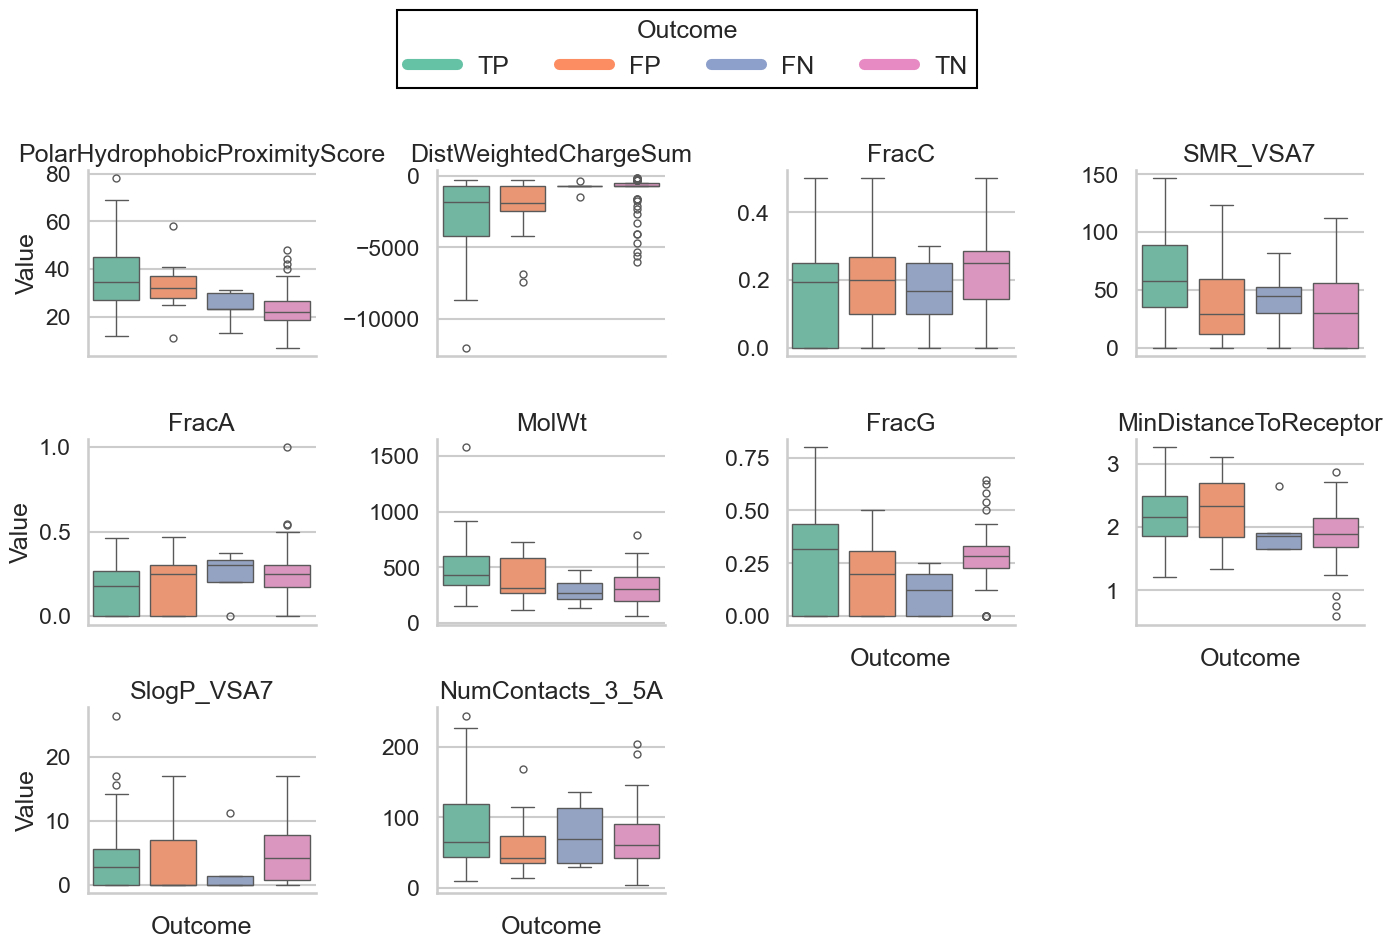

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === Load merged prediction + feature data
df = pd.read_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features.csv"))

# === Top 10 mean(|SHAP|) features (provided)
top_features = [
    "PolarHydrophobicProximityScore",
    "DistWeightedChargeSum",
    "FracC",
    "SMR_VSA7",
    "FracA",
    "MolWt",
    "FracG",
    "MinDistanceToReceptor",
    "SlogP_VSA7",
    "NumContacts_3_5A",
]
# === Sanity checks
if "Outcome" not in df.columns:
    raise KeyError("Expected an 'Outcome' column in naffinity_test_predictions_with_features.csv")

available = [f for f in top_features if f in df.columns]
missing = [f for f in top_features if f not in df.columns]

print(f"✅ Found {len(available)}/{len(top_features)} requested SHAP features in the merged file.")
if missing:
    print("⚠️ Missing features (not present as columns in the merged CSV):")
    for m in missing:
        print("  -", m)

# === Filter to relevant outcomes + columns
plot_df = df[df["Outcome"].isin(["TP", "FP", "FN", "TN"])][["Outcome"] + available].copy()

# Coerce numeric and clean NaN/inf
for c in available:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")
plot_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# === Reshape for plotting
df_melted = plot_df.melt(
    id_vars="Outcome",
    value_vars=available,
    var_name="Feature",
    value_name="Value"
).dropna(subset=["Value"])

# === Consistent palette for outcome
palette = {
    "TP": "#66c2a5",
    "FP": "#fc8d62",
    "FN": "#8da0cb",
    "TN": "#e78ac3",
}

sns.set(style="whitegrid", context="talk")

# === Boxplot grid
g = sns.catplot(
    data=df_melted,
    x="Outcome",
    y="Value",
    col="Feature",
    kind="box",
    col_wrap=4,
    sharey=False,
    order=["TP", "FP", "FN", "TN"],
    palette=palette,
    height=3.2,
    aspect=1.1
)

# === Legend (moved ABOVE plots so it doesn't overlap)
handles = [plt.Line2D([0], [0], color=palette[o], lw=8) for o in ["TP", "FP", "FN", "TN"]]
g.fig.legend(
    handles,
    ["TP", "FP", "FN", "TN"],
    title="Outcome",
    loc="upper center",
    ncol=4,
    fontsize="medium",
    frameon=True,
    bbox_to_anchor=(0.5, 1.03)  # push legend above the axes grid
)

# === Final formatting
g.set_titles("{col_name}")
g.set_xticklabels(rotation=30)

# Reserve space at the top for the legend
g.fig.subplots_adjust(top=0.85)

g.fig.suptitle("", fontsize=16)
plt.show()

## Figure S8


In [35]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")



Train rows: 1062 | Test rows: 117 | Raw features: 302

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.8120
  Precision: 0.6792
  Recall   : 0.8780
  F1 Score : 0.7660


Brier score: 0.1197


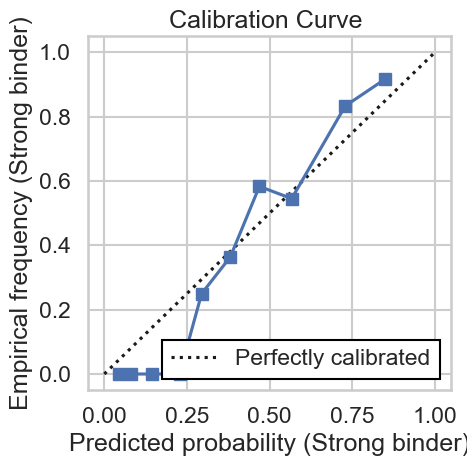

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

# Assumes you already ran the current pipeline code and have:
#   - rf_pipeline (fit)
#   - X_test_raw
#   - y_test

# ── 1. Get predicted probabilities on the held-out Stratified test set ──
y_true = y_test.to_numpy().astype(int) if hasattr(y_test, "to_numpy") else np.asarray(y_test, dtype=int)

if hasattr(rf_pipeline, "predict_proba"):
    y_prob = rf_pipeline.predict_proba(X_test_raw)[:, 1]
else:
    raise RuntimeError("rf_pipeline does not support predict_proba().")

# ── 2. Brier score ─────────────────────────────────────────────────────
brier = brier_score_loss(y_true, y_prob)
print(f"Brier score: {brier:.4f}")

# ── 3. Calibration / reliability plot ─────────────────────────────────
# Use equal-frequency (quantile) binning
prob_true, prob_pred = calibration_curve(
    y_true, y_prob, n_bins=10, strategy="quantile"
)

fig, ax = plt.subplots(figsize=(5, 5))
CalibrationDisplay(prob_true, prob_pred, y_prob).plot(ax=ax)
ax.set_title("Calibration Curve ")
ax.set_xlabel("Predicted probability (Strong binder)")
ax.set_ylabel("Empirical frequency (Strong binder)")
ax.grid(True)
plt.tight_layout()
plt.show()


## Table S6


In [45]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# These supplementary tables were generated with the pinned repository environment.
import sklearn
if sklearn.__version__ != "1.3.2":
    raise RuntimeError(
        "Tables S6 and S7 require scikit-learn 1.3.2. "
        "Create the environment from ../environment.yml before rerunning."
    )

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

# ============================================================
# Buffer-zone sample weighting
# Reviewer suggestion:
# Strong <= 0.5 μM
# Buffer = 0.5–10 μM
# Weak >= 10 μM
# ============================================================

# ============================================================
# Buffer-zone weighting sweep
# ============================================================

BUFFER_WEIGHTS = [
    1.00,   # original model
    0.50,
    0.25,
    0.10
]


X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================

# ============================================================
# Train model
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

results = []

for BUFFER_WEIGHT in BUFFER_WEIGHTS:

    print(
        "\n" + "=" * 60
    )
    print(
        f"BUFFER WEIGHT = {BUFFER_WEIGHT}"
    )
    print(
        "=" * 60
    )

    sample_weights = np.ones(
        len(train_df)
    )

    buffer_mask = (
        (train_df["AffinityValue"] > 5e-7)
        &
        (train_df["AffinityValue"] < 1e-5)
    )

    sample_weights[
        buffer_mask
    ] = BUFFER_WEIGHT

    print(
        f"Buffer samples: "
        f"{buffer_mask.sum()}"
    )

    rf_pipeline = Pipeline([
        ("clean",
         NumericCleaner(
             clip_to_float32=True
         )),
        ("drop_const",
         DropConstantColumns()),
        ("corr",
         CorrelationFilter(
             threshold=CORR_THRESHOLD,
             method=CORR_METHOD
         )),
        ("clf",
         RandomForestClassifier(
             **RF_PARAMS
         )),
    ])

    rf_pipeline.fit(
        X_train_raw,
        y_train,
        clf__sample_weight=sample_weights
    )

    probs = (
        rf_pipeline
        .predict_proba(
            X_test_raw
        )[:, 1]
    )

    preds = (
        probs >= 0.38
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        preds
    )

    auroc = roc_auc_score(
        y_test,
        probs
    )

    auprc = average_precision_score(
        y_test,
        probs
    )

    results.append({
        "BufferWeight":
            BUFFER_WEIGHT,
        "Accuracy":
            accuracy,
        "Precision":
            precision,
        "Recall":
            recall,
        "F1":
            f1,
        "AUROC":
            auroc,
        "AUPRC":
            auprc
    })

    print(
        f"Accuracy : {accuracy:.4f}"
    )
    print(
        f"Precision: {precision:.4f}"
    )
    print(
        f"Recall   : {recall:.4f}"
    )
    print(
        f"F1       : {f1:.4f}"
    )
    print(
        f"AUROC    : {auroc:.4f}"
    )
    print(
        f"AUPRC    : {auprc:.4f}"
    )

print(
    "\n\nFINAL SUMMARY"
)
print(
    pd.DataFrame(results)
    .round(4)
)

Train rows: 1062 | Test rows: 117 | Raw features: 302

BUFFER WEIGHT = 1.0
Buffer samples: 322
Accuracy : 0.8120
Precision: 0.6792
Recall   : 0.8780
F1       : 0.7660
AUROC    : 0.9178
AUPRC    : 0.8562

BUFFER WEIGHT = 0.5
Buffer samples: 322
Accuracy : 0.8120
Precision: 0.6792
Recall   : 0.8780
F1       : 0.7660
AUROC    : 0.9108
AUPRC    : 0.8398

BUFFER WEIGHT = 0.25
Buffer samples: 322
Accuracy : 0.8205
Precision: 0.6852
Recall   : 0.9024
F1       : 0.7789
AUROC    : 0.9108
AUPRC    : 0.8414

BUFFER WEIGHT = 0.1
Buffer samples: 322
Accuracy : 0.8120
Precision: 0.6667
Recall   : 0.9268
F1       : 0.7755
AUROC    : 0.9024
AUPRC    : 0.8106


FINAL SUMMARY
   BufferWeight  Accuracy  Precision  Recall      F1   AUROC   AUPRC
0          1.00    0.8120     0.6792  0.8780  0.7660  0.9178  0.8562
1          0.50    0.8120     0.6792  0.8780  0.7660  0.9108  0.8398
2          0.25    0.8205     0.6852  0.9024  0.7789  0.9108  0.8414
3          0.10    0.8120     0.6667  0.9268  0.7755  0.9

## Table S7


In [46]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# These supplementary tables were generated with the pinned repository environment.
import sklearn
if sklearn.__version__ != "1.3.2":
    raise RuntimeError(
        "Tables S6 and S7 require scikit-learn 1.3.2. "
        "Create the environment from ../environment.yml before rerunning."
    )

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CUTOFFS_UM = [0.5, 1.0, 5.0, 10.0]
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)


X_test_raw = test_df[feature_cols].reset_index(drop=True)


print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

results = []

for cutoff_um in CUTOFFS_UM:

    cutoff_M = cutoff_um * 1e-6

    print("\n" + "=" * 60)
    print(f"CUTOFF = {cutoff_um} μM")
    print("=" * 60)

    y_train = (
        train_df["AffinityValue"] < cutoff_M
    ).astype(int)

    y_test = (
        test_df["AffinityValue"] < cutoff_M
    ).astype(int)

    print(
        f"Train strong: {y_train.sum()} | "
        f"Weak: {(1-y_train).sum()}"
    )

    print(
        f"Test strong: {y_test.sum()} | "
        f"Weak: {(1-y_test).sum()}"
    )

    rf_pipeline = Pipeline([
        ("clean", NumericCleaner(
            clip_to_float32=True
        )),
        ("drop_const", DropConstantColumns()),
        ("corr", CorrelationFilter(
            threshold=CORR_THRESHOLD,
            method=CORR_METHOD
        )),
        ("clf", RandomForestClassifier(
            **RF_PARAMS
        )),
    ])

    rf_pipeline.fit(
        X_train_raw,
        y_train
    )

    probs = (
        rf_pipeline
        .predict_proba(X_test_raw)[:,1]
    )

    preds = (
        probs >= 0.38
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        preds
    )

    auroc = roc_auc_score(
        y_test,
        probs
    )

    auprc = average_precision_score(
        y_test,
        probs
    )

    results.append({

        "Cutoff_uM": cutoff_um,

        "StrongTrain": int(y_train.sum()),

        "WeakTrain": int((1-y_train).sum()),

        "StrongTest": int(y_test.sum()),

        "WeakTest": int((1-y_test).sum()),

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "AUROC": auroc,

        "AUPRC": auprc

    })

    print(
        f"Accuracy : {accuracy:.4f}"
    )
    print(
        f"Precision: {precision:.4f}"
    )
    print(
        f"Recall   : {recall:.4f}"
    )
    print(
        f"F1       : {f1:.4f}"
    )
    print(
        f"AUROC    : {auroc:.4f}"
    )
    print(
        f"AUPRC    : {auprc:.4f}"
    )

print("\n\nFINAL SUMMARY")
print(
    pd.DataFrame(results)
    .round(4)
)

Train rows: 1062 | Test rows: 117 | Raw features: 302

CUTOFF = 0.5 μM
Train strong: 271 | Weak: 791
Test strong: 30 | Weak: 87
Accuracy : 0.7949
Precision: 0.5750
Recall   : 0.7667
F1       : 0.6571
AUROC    : 0.8755
AUPRC    : 0.6777

CUTOFF = 1.0 μM
Train strong: 352 | Weak: 710
Test strong: 41 | Weak: 76
Accuracy : 0.8120
Precision: 0.6792
Recall   : 0.8780
F1       : 0.7660
AUROC    : 0.9178
AUPRC    : 0.8562

CUTOFF = 5.0 μM
Train strong: 534 | Weak: 528
Test strong: 54 | Weak: 63
Accuracy : 0.8462
Precision: 0.7647
Recall   : 0.9630
F1       : 0.8525
AUROC    : 0.9359
AUPRC    : 0.9243

CUTOFF = 10.0 μM
Train strong: 605 | Weak: 457
Test strong: 63 | Weak: 54
Accuracy : 0.8120
Precision: 0.7470
Recall   : 0.9841
F1       : 0.8493
AUROC    : 0.9312
AUPRC    : 0.9473


FINAL SUMMARY
   Cutoff_uM  StrongTrain  WeakTrain  StrongTest  WeakTest  Accuracy  \
0        0.5          271        791          30        87    0.7949   
1        1.0          352        710          41        7

## Figure S9


In [39]:
import pandas as pd
from pathlib import Path

pred = pd.read_csv(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_detailed.csv"))
meta = pd.read_csv(str(DATA_DIR / "archived_test_predictions_metadata.csv"))
columns = ["Folder", "PoseType", "AffinityMethod", "Resolution", "ResolutionBin"]
assert meta["Folder"].is_unique and pred["Folder"].is_unique
df = pred.merge(meta[columns], on="Folder", how="left", validate="one_to_one")
assert len(df) == 117 and df["PoseType"].notna().all(), "Metadata coverage must be complete"
df["Outcome"] = df.apply(lambda r: ("TP" if r.TrueLabel == 1 else "FP") if r.PredictedLabel == 1 else ("FN" if r.TrueLabel == 1 else "TN"), axis=1)
out_path = Path(str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_metadata.csv"))
df.to_csv(out_path, index=False)



=== Accuracy by Pose Origin ===
       PoseType  count      mean       std       SEM  CI95_low  CI95_high
0        Docked     70  0.842857  0.366563  0.043813  0.756984   0.928730
1  Experimental     47  0.765957  0.427976  0.062427  0.643601   0.888314


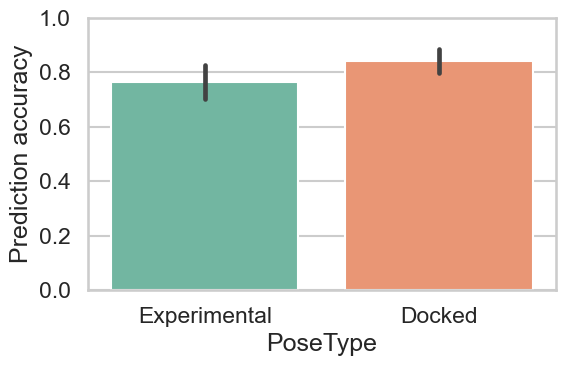

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load data
file_path = str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_metadata.csv")
df = pd.read_csv(file_path)
df["PoseType"] = df["PoseType"].replace("Crystal", "Experimental")

# Ensure Correct is numeric 0/1
if df["Correct"].dtype == bool:
    df["Correct"] = df["Correct"].astype(int)
else:
    df["Correct"] = df["Correct"].map(
        lambda x: 1 if str(x).strip().lower() in ["1","true","t","yes"] else 0
    ).astype(int)

sns.set(style="whitegrid", context="talk")
palette = sns.color_palette("Set2")

def summarize_accuracy(data, group_col):
    summary = (
        data.groupby(group_col)["Correct"]
        .agg(["count", "mean", "std"])
        .reset_index()
    )
    summary["SEM"] = summary["std"] / np.sqrt(summary["count"])
    summary["CI95_low"] = summary["mean"] - 1.96 * summary["SEM"]
    summary["CI95_high"] = summary["mean"] + 1.96 * summary["SEM"]
    return summary

# =========================
# 1. Accuracy by Pose Origin
# =========================
summary_pose = summarize_accuracy(df, "PoseType")
print("\n=== Accuracy by Pose Origin ===")
print(summary_pose)

plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="PoseType",
    y="Correct",
    estimator=np.mean,
    errorbar="se",
    palette=palette
)
plt.ylabel("Prediction accuracy")
plt.ylim(0,1)
plt.tight_layout()
plt.show()



## Figure S10



=== Accuracy by Affinity Method ===
  AffinityMethodBinned  count      mean       std       SEM  CI95_low  \
0            $IC_{50}$     12  0.916667  0.288675  0.083333  0.753333   
1                $K_d$     90  0.788889  0.410383  0.043258  0.704103   
2                Other     15  0.866667  0.351866  0.090851  0.688598   

   CI95_high  
0   1.080000  
1   0.873675  
2   1.044735  


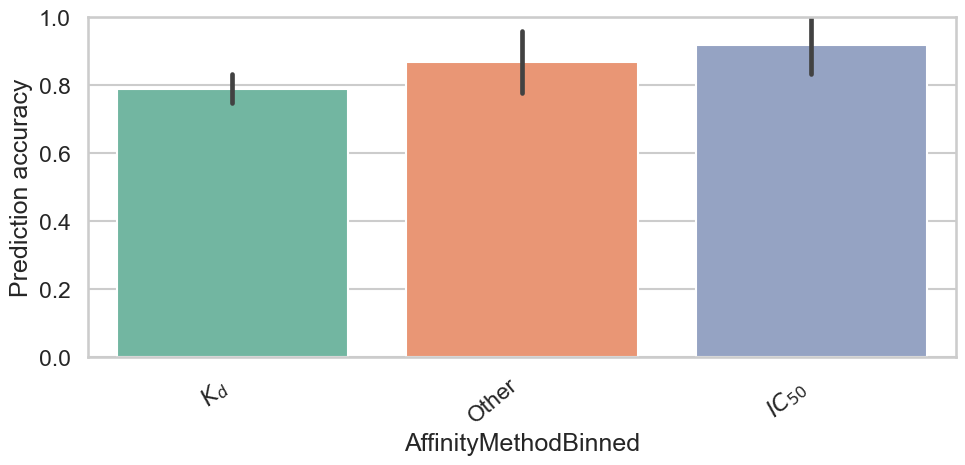

In [41]:
# =========================
# 2. Accuracy by Affinity Method
# =========================
def bin_affinity_method(method):
    m = str(method).strip().upper()
    if m.startswith("KD") or m == "K_D":
        return "KD"
    if m.startswith("IC") or "IC50" in m or "IC_50" in m:
        return "IC"
    return "Other"

df["AffinityMethodBinned"] = df["AffinityMethod"].apply(bin_affinity_method)
df["AffinityMethodBinned"] = df["AffinityMethodBinned"].replace({
    "KD": r"$K_d$",
    "IC": r"$IC_{50}$"
})

summary_aff = summarize_accuracy(df, "AffinityMethodBinned")
print("\n=== Accuracy by Affinity Method ===")
print(summary_aff)

plt.figure(figsize=(10,5))
order = df["AffinityMethodBinned"].value_counts().index.tolist()
sns.barplot(
    data=df,
    x="AffinityMethodBinned",
    y="Correct",
    order=order,
    estimator=np.mean,
    errorbar="se",
    palette=palette
)
plt.ylabel("Prediction accuracy")
plt.ylim(0,1)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()



## Figure S11


In [ ]:
# =========================
# 3. Accuracy by Resolution
# =========================
df_res = df.copy()
df_res["Resolution"] = pd.to_numeric(df_res["Resolution"], errors="coerce")

def bin_resolution(res):
    if pd.isna(res):
        return np.nan
    if res < 2.0:
        return "0–2 Å"
    if res < 3.0:
        return "2–3 Å"
    if res < 4.0:
        return "3–4 Å"
    return np.nan

df_res["ResolutionBin"] = df_res["Resolution"].apply(bin_resolution)
df_res = df_res[df_res["ResolutionBin"].notna()].copy()

summary_res = summarize_accuracy(df_res, "ResolutionBin")
print("\n=== Accuracy by Resolution ===")
print(summary_res)

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_res,
    x="ResolutionBin",
    y="Correct",
    order=["0–2 Å","2–3 Å","3–4 Å"],
    estimator=np.mean,
    errorbar="se",
    palette=palette
)
plt.ylabel("Prediction accuracy")
plt.xlabel("")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

## Figure S12


In [42]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# Settings
# ============================================================
dataset_path = str(DATA_DIR / "naffinity_dataset.csv")
CORR_METHOD = "spearman"
CORR_THRESHOLD = 0.75
RANDOM_STATE = 42

# Best hyperparameters (from your GridSearchCV selected by mean_test_f1)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=False,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1

)
# ============================================================
# Fold-safe preprocessing components (fit on TRAIN ONLY)
# ============================================================
class NumericCleaner(BaseEstimator, TransformerMixin):
    """
    Transform:
      - coerce to numeric
      - inf/-inf -> NaN -> 0
      - clip to float32 range to avoid overflow in estimators
    """
    def __init__(self, clip_to_float32=True):
        self.clip_to_float32 = clip_to_float32

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        if self.clip_to_float32:
            f32max = np.finfo(np.float32).max
            X = X.clip(lower=-f32max, upper=f32max)
        return X


class DropConstantColumns(BaseEstimator, TransformerMixin):
    """Fit on TRAIN only: drop columns with <=1 unique value in TRAIN."""
    def __init__(self):
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        nunique = X.nunique(dropna=False)
        self.keep_cols_ = nunique[nunique > 1].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Fit on TRAIN only:
      - compute correlation matrix (Spearman)
      - drop one of each pair with |corr| > threshold (upper triangle)
    """
    def __init__(self, threshold=0.75, method="spearman"):
        self.threshold = float(threshold)
        self.method = method
        self.keep_cols_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if X.shape[1] <= 1:
            self.keep_cols_ = X.columns.tolist()
            return self

        corr = X.corr(method=self.method).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop = [c for c in upper.columns if (upper[c] > self.threshold).any()]
        self.keep_cols_ = [c for c in X.columns if c not in set(to_drop)]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.reindex(columns=self.keep_cols_, fill_value=0.0)


# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv(dataset_path)

# Split train/test (test is Stratified)
train_df = df[df["Split"] == "Train"].copy()
test_df  = df[df["Split"] == "Stratified"].copy()

# Define features and labels
drop_cols = ["AffinityValue", "Label", "Folder", "Split"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train_raw = train_df[feature_cols].reset_index(drop=True)
y_train = train_df["Label"].astype(int).reset_index(drop=True)

X_test_raw = test_df[feature_cols].reset_index(drop=True)
y_test = test_df["Label"].astype(int).reset_index(drop=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)} | Raw features: {len(feature_cols)}")

# ============================================================
# Final pipeline (fit preprocessing on TRAIN ONLY, then model)
# ============================================================
rf_pipeline = Pipeline([
    ("clean", NumericCleaner(clip_to_float32=True)),
    ("drop_const", DropConstantColumns()),
    ("corr", CorrelationFilter(threshold=CORR_THRESHOLD, method=CORR_METHOD)),
    ("clf", RandomForestClassifier(**RF_PARAMS)),
])

# ============================================================
# Train model
# ============================================================
rf_pipeline.fit(X_train_raw, y_train)

# ============================================================
# Final feature set used by the model
# ============================================================

final_features = (
    rf_pipeline
    .named_steps["corr"]
    .keep_cols_
)

print("\n==============================")
print("FINAL MODEL FEATURES")
print("==============================")
print(f"Raw features: {len(feature_cols)}")
print(f"Final features: {len(final_features)}")

feature_df = pd.DataFrame({
    "Feature": final_features
})

feature_df.to_csv(
    str(REPRO_OUTPUT_DIR / "naffinity_final_features.csv"),
    index=False
)

print(
    "\nSaved feature list to:\n",
    str(REPRO_OUTPUT_DIR / "naffinity_final_features.csv")
)

# ============================================================
# Predict using optimized threshold
# ============================================================
OPTIMAL_THRESHOLD = 0.38

rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]
rf_preds = (rf_probs >= OPTIMAL_THRESHOLD).astype(int)

# ============================================================
# Evaluation
# ============================================================
print(
    f"\n🎯 Evaluation Metrics "
    f"(Random Forest on Stratified Test Set, threshold={OPTIMAL_THRESHOLD})"
)

print(f"  Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision: {precision_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_preds, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_test, rf_preds):.4f}")

label_map = {
    0: "Weak Binders (≥1 μM)",
    1: "Strong Binders (<1 μM)"
}

y_test_named = y_test.map(label_map)
rf_named = pd.Series(rf_preds).map(label_map)

print(
    "\n"
    + classification_report(
        y_test_named,
        rf_named,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# Confusion matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    rf_preds,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

accuracy_weak = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

accuracy_strong = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print(
    "\n📊 Confusion Matrix "
    "(rows=true, cols=pred; order=[Weak, Strong])"
)
print(cm)

print("\n📊 Per-Class Accuracy:")
print(
    f"  Weak Binders (≥1 μM):   "
    f"{accuracy_weak:.4f}"
)
print(
    f"  Strong Binders (<1 μM): "
    f"{accuracy_strong:.4f}"
)

# ============================================================
# Additional probability diagnostics
# ============================================================
print("\n📈 Probability Summary")
print(
    f"Mean predicted strong-binding probability: "
    f"{rf_probs.mean():.4f}"
)

print(
    f"Predicted strong binders @ threshold "
    f"{OPTIMAL_THRESHOLD}: "
    f"{rf_preds.sum()} / {len(rf_preds)} "
    f"({100 * rf_preds.mean():.1f}%)"
)

X_train_final = (
    rf_pipeline[:-1]
    .transform(X_train_raw)
)

print(
    f"\nTransformed shape: "
    f"{X_train_final.shape}"
)

Train rows: 1062 | Test rows: 117 | Raw features: 302

FINAL MODEL FEATURES
Raw features: 302
Final features: 131

Saved feature list to:
 results/naffinity_final_features.csv

🎯 Evaluation Metrics (Random Forest on Stratified Test Set, threshold=0.38)
  Accuracy : 0.8120
  Precision: 0.6792
  Recall   : 0.8780
  F1 Score : 0.7660

                        precision    recall  f1-score   support

Strong Binders (<1 μM)     0.6792    0.8780    0.7660        41
  Weak Binders (≥1 μM)     0.9219    0.7763    0.8429        76

              accuracy                         0.8120       117
             macro avg     0.8006    0.8272    0.8044       117
          weighted avg     0.8369    0.8120    0.8159       117


📊 Confusion Matrix (rows=true, cols=pred; order=[Weak, Strong])
[[59 17]
 [ 5 36]]

📊 Per-Class Accuracy:
  Weak Binders (≥1 μM):   0.7763
  Strong Binders (<1 μM): 0.8780

📈 Probability Summary
Mean predicted strong-binding probability: 0.3790
Predicted strong binders @ thresh


Shared apo/holo complexes: 66
Apo/holo t-SNE uses 128 measured shared features


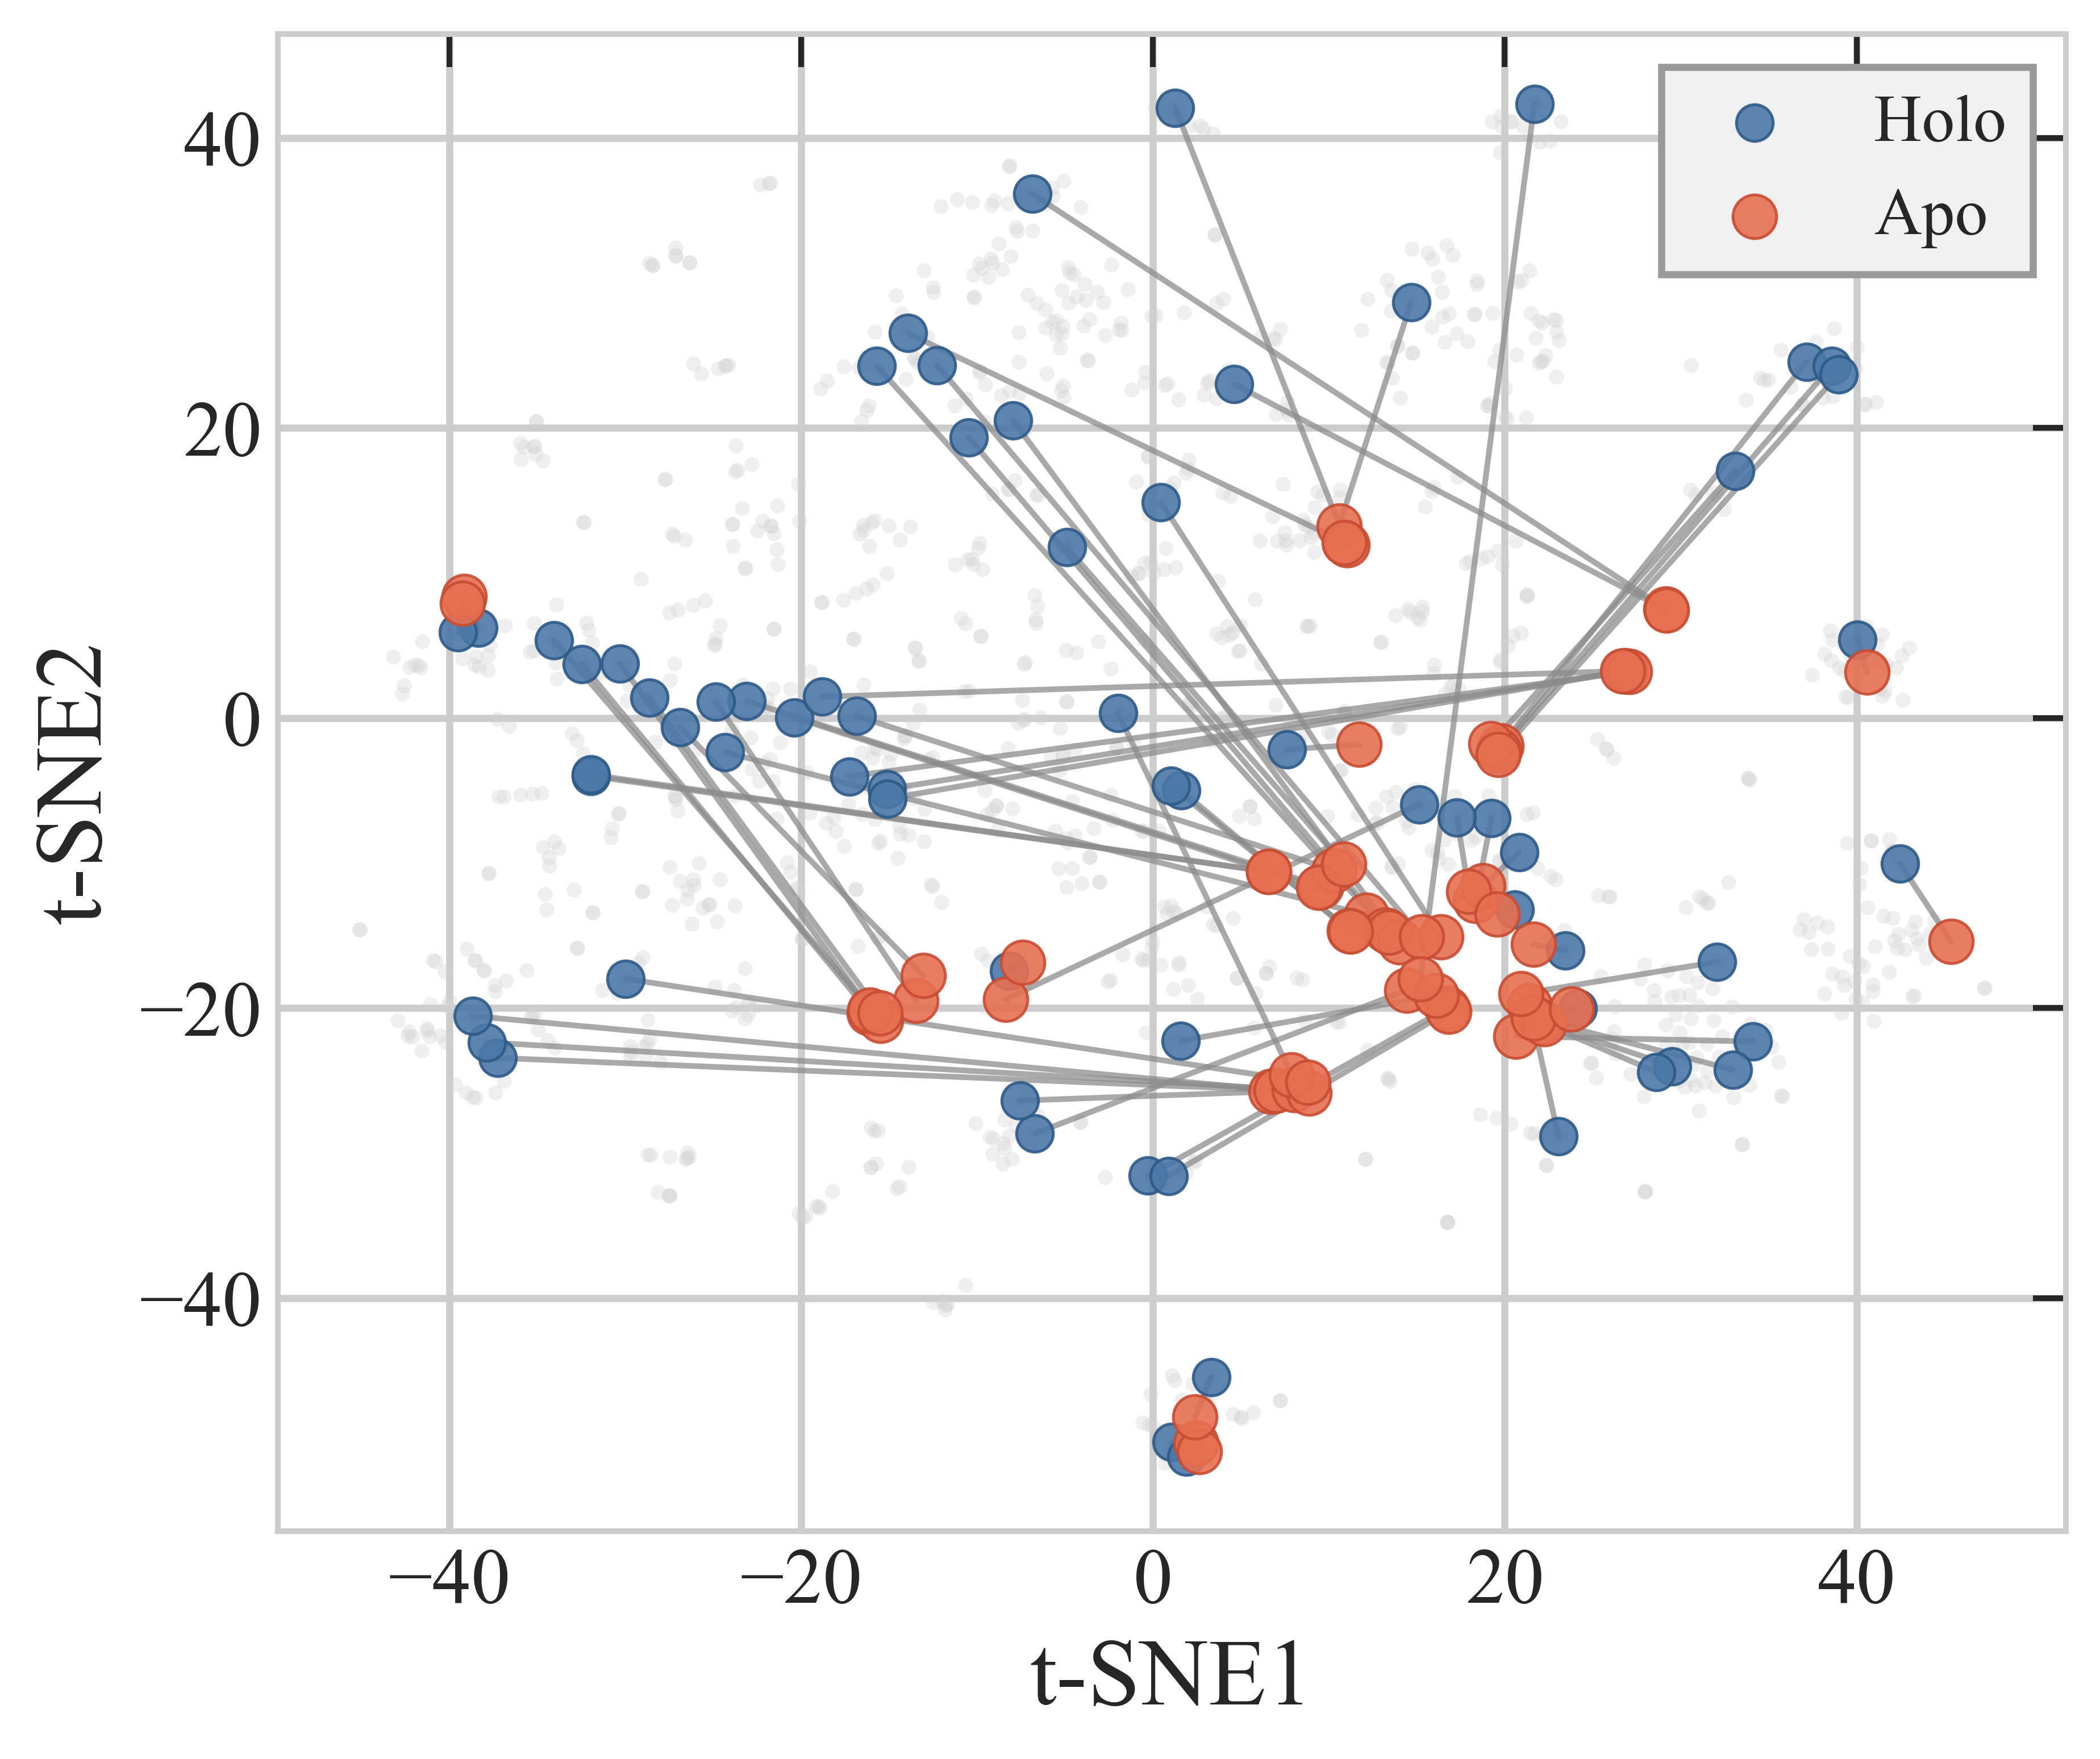

In [43]:
# ============================================================
# Apo vs Holo t-SNE in full NAffinity feature space
# ============================================================

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

full_holo_df = pd.read_csv(
    str(DATA_DIR / "naffinity_dataset.csv")
)

apo_df = pd.read_csv(
    str(DATA_DIR / "naffinity_apo_dataset.csv")
)

# ------------------------------------------------------------
# Keep only complexes present in both datasets
# ------------------------------------------------------------

shared_folders = sorted(
    set(full_holo_df["Folder"])
    &
    set(apo_df["Folder"])
)

print(
    f"\nShared apo/holo complexes: "
    f"{len(shared_folders)}"
)

# ------------------------------------------------------------
# Full holo feature space (all complexes)
# ------------------------------------------------------------

common_features = [feature for feature in final_features if feature in apo_df.columns]
assert len(common_features) == 128, "Expected 128 measured model features shared by holo and apo datasets"
print(f"Apo/holo t-SNE uses {len(common_features)} measured shared features")
X_full_holo = full_holo_df[common_features].copy()

# ------------------------------------------------------------
# Shared holo subset
# ------------------------------------------------------------

holo_subset = (
    full_holo_df[
        full_holo_df["Folder"].isin(shared_folders)
    ]
    .sort_values("Folder")
    .reset_index(drop=True)
)

X_holo_subset = holo_subset[common_features]

# ------------------------------------------------------------
# Shared apo subset
# ------------------------------------------------------------

apo_subset = (
    apo_df[
        apo_df["Folder"].isin(shared_folders)
    ]
    .sort_values("Folder")
    .reset_index(drop=True)
)

X_apo_subset = apo_subset[common_features]

# ------------------------------------------------------------
# Combine full holo space + apo structures
# ------------------------------------------------------------

X_combined = pd.concat(
    [
        X_full_holo,
        X_apo_subset
    ],
    axis=0,
    ignore_index=True
)

# ------------------------------------------------------------
# Standardize
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_combined
)

# ------------------------------------------------------------
# t-SNE
# ------------------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

coords = tsne.fit_transform(
    X_scaled
)

# ------------------------------------------------------------
# Build plotting dataframes
# ------------------------------------------------------------

n_full = len(X_full_holo)

full_plot_df = pd.DataFrame({
    "tSNE1": coords[:n_full, 0],
    "tSNE2": coords[:n_full, 1],
    "Folder": full_holo_df["Folder"]
})

apo_plot_df = pd.DataFrame({
    "tSNE1": coords[n_full:, 0],
    "tSNE2": coords[n_full:, 1],
    "Folder": apo_subset["Folder"]
})

# ------------------------------------------------------------
# Get coordinates of corresponding holo complexes
# ------------------------------------------------------------

holo_highlight_df = (
    full_plot_df[
        full_plot_df["Folder"].isin(shared_folders)
    ]
    .sort_values("Folder")
    .reset_index(drop=True)
)

apo_plot_df = (
    apo_plot_df
    .sort_values("Folder")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Origin-style plotting
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.linewidth": 1.2,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 7,
    "ytick.major.size": 7,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
})

fig, ax = plt.subplots(
    figsize=(6.5, 5.5),
    dpi=600
)

# ------------------------------------------------------------
# Background feature space
# ------------------------------------------------------------

ax.scatter(
    full_plot_df["tSNE1"],
    full_plot_df["tSNE2"],
    s=10,
    c="lightgray",
    alpha=0.35,
    linewidths=0,
    zorder=1
)

# ------------------------------------------------------------
# Apo-Holo pair connections
# ------------------------------------------------------------

for i in range(len(holo_highlight_df)):

    ax.plot(
        [
            holo_highlight_df.iloc[i]["tSNE1"],
            apo_plot_df.iloc[i]["tSNE1"]
        ],
        [
            holo_highlight_df.iloc[i]["tSNE2"],
            apo_plot_df.iloc[i]["tSNE2"]
        ],
        color="0.55",
        linewidth=1.2,
        alpha=0.75,
        zorder=2
    )
# ------------------------------------------------------------
# Holo complexes
# ------------------------------------------------------------

ax.scatter(
    holo_highlight_df["tSNE1"],
    holo_highlight_df["tSNE2"],
    s=60,
    c="#4C78A8",
    edgecolors="#2E5A88",
    linewidths=0.6,
    alpha=0.90,
    label="Holo",
    zorder=4
)

# ------------------------------------------------------------
# Apo complexes
# ------------------------------------------------------------

ax.scatter(
    apo_plot_df["tSNE1"],
    apo_plot_df["tSNE2"],
    s=85,
    c="#E76F51",
    edgecolors="#C74D33",
    linewidths=0.6,
    alpha=0.90,
    label="Apo",
    zorder=5
)

# ------------------------------------------------------------
# Labels and styling
# ------------------------------------------------------------

ax.set_xlabel("t-SNE1", fontsize=20)
ax.set_ylabel("t-SNE2", fontsize=20)

leg = ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=14,
    loc="best"
)

leg.get_frame().set_facecolor("#f0f0f0")
leg.get_frame().set_alpha(1.0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

## Figure S13


Matched test complexes: 117
Outcome
TP    36
TN    59
FP    17
FN     5
Name: count, dtype: int64


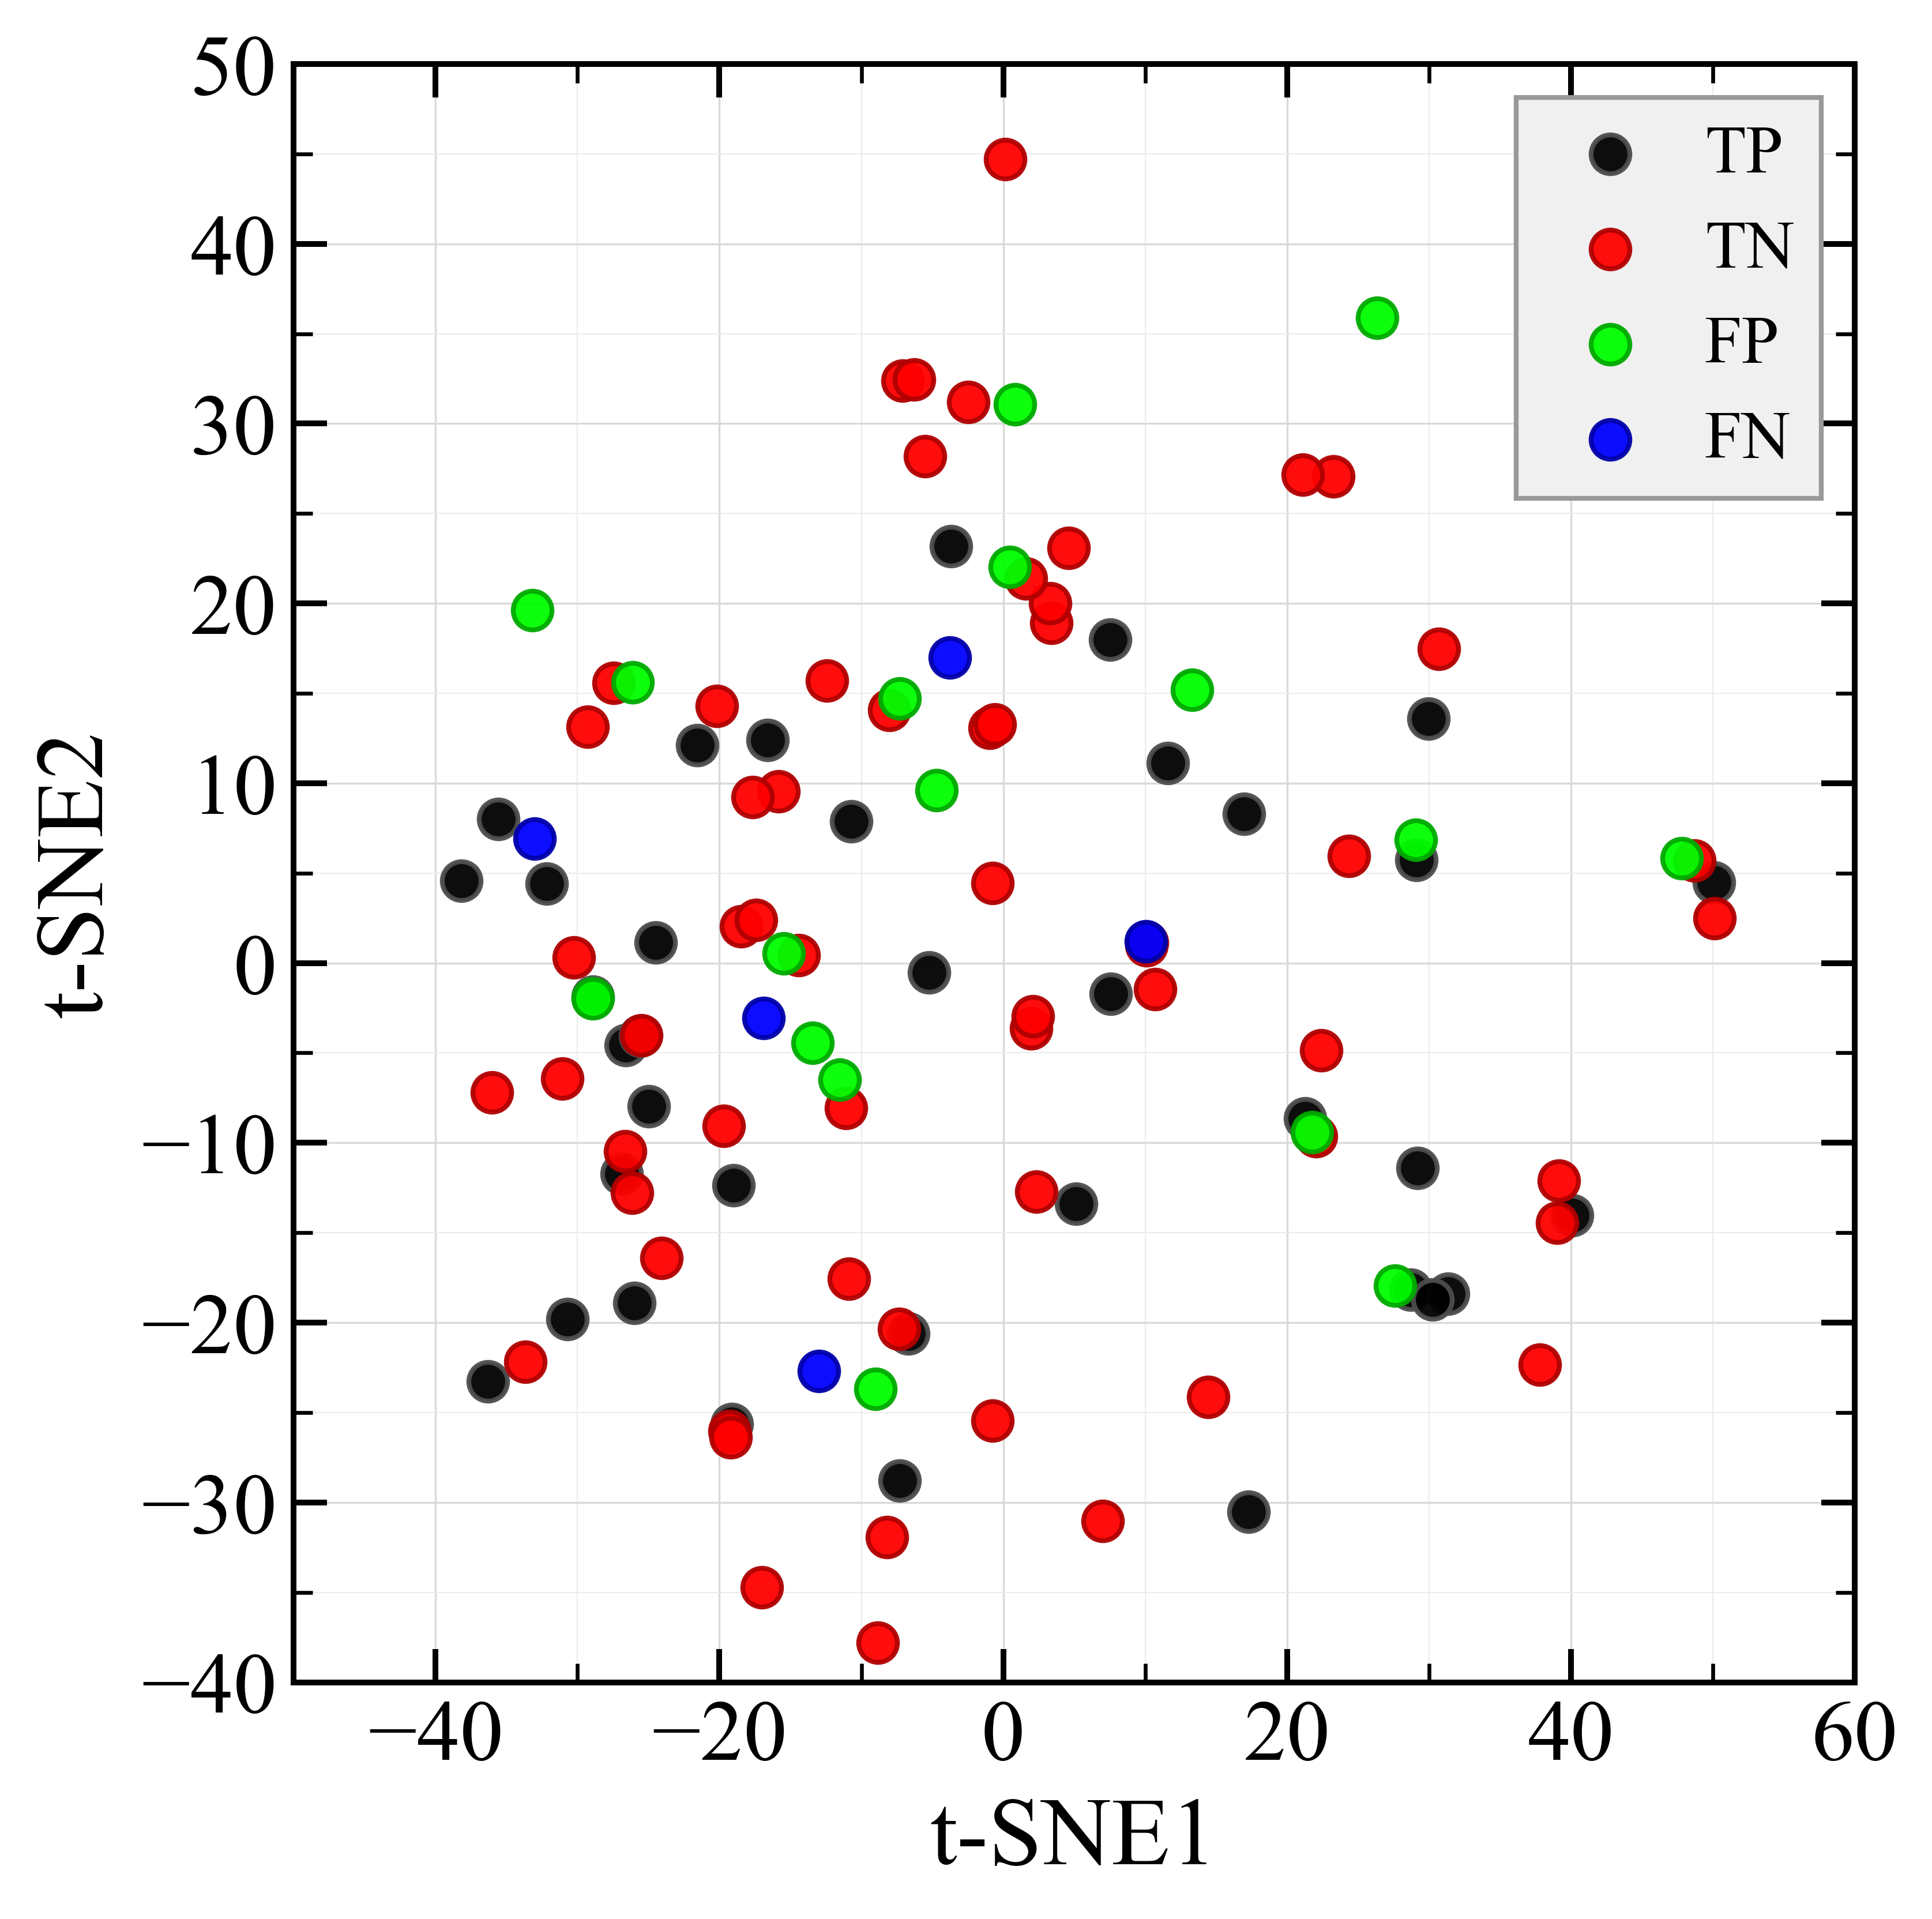

In [3]:
# ============================================================
# Figure S13: Model outcomes in t-SNE feature space
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Load t-SNE coordinates for the complete dataset and predictions
# for the 117 held-out test complexes.
coordinates = pd.read_csv(DATA_DIR / "figure_s2_coordinates.csv")
predictions = pd.read_csv(
    DATA_DIR / "archived_test_predictions_metadata.csv"
)

# Normalize identifiers before matching.
coordinates["_folder_key"] = (
    coordinates["Folder"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

predictions["_folder_key"] = (
    predictions["Folder"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

# Confirm that identifiers are unique.
assert coordinates["_folder_key"].is_unique
assert predictions["_folder_key"].is_unique

# Match every test complex to its own t-SNE coordinates.
plot_df = predictions[
    ["Folder", "Outcome", "_folder_key"]
].merge(
    coordinates[
        ["_folder_key", "tSNE1", "tSNE2"]
    ],
    on="_folder_key",
    how="left",
    validate="one_to_one"
)

# Verify that all 117 test complexes were matched.
missing = plot_df.loc[
    plot_df[["tSNE1", "tSNE2"]].isna().any(axis=1),
    "Folder"
].tolist()

assert not missing, (
    "Missing t-SNE coordinates for: "
    + ", ".join(missing)
)

assert len(plot_df) == 117
assert set(plot_df["Outcome"]) == {"TP", "TN", "FP", "FN"}

# Save the correctly matched plotting data.
plot_df[
    ["Folder", "tSNE1", "tSNE2", "Outcome"]
].to_csv(
    DATA_DIR / "figure_s13_coordinates_outcomes.csv",
    index=False
)

print(f"Matched test complexes: {len(plot_df)}")
print(plot_df["Outcome"].value_counts().reindex(
    ["TP", "TN", "FP", "FN"]
))

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
})

colors = {
    "TP": ("black", "0.3"),
    "TN": ("red", "#b00000"),
    "FP": ("lime", "#00aa00"),
    "FN": ("blue", "#0000aa"),
}

fig, ax = plt.subplots(figsize=(5.8, 5.8), dpi=600)

for outcome in ["TP", "TN", "FP", "FN"]:
    subset = plot_df.loc[plot_df["Outcome"] == outcome]
    face_color, edge_color = colors[outcome]

    ax.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        s=65,
        c=face_color,
        edgecolors=edge_color,
        linewidths=1.0,
        alpha=0.95,
        label=outcome,
        zorder=3
    )

ax.grid(
    which="major",
    linestyle="-",
    linewidth=0.4,
    color="0.85"
)

ax.grid(
    which="minor",
    linestyle="-",
    linewidth=0.25,
    color="0.92"
)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.set_xlabel("t-SNE1", fontsize=20)
ax.set_ylabel("t-SNE2", fontsize=20)
ax.set_xlim(-50, 60)
ax.set_ylim(-40, 50)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=14,
    handletextpad=0.4
)

legend.get_frame().set_facecolor("#f0f0f0")
legend.get_frame().set_alpha(1.0)

plt.tight_layout()

plt.savefig(
    REPRO_OUTPUT_DIR / "Figure_S13_tSNE_outcomes.tiff",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

## Figure S14


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ============================================================
# Load data
# ============================================================

df = pd.read_csv(
    str(REPRO_OUTPUT_DIR / "naffinity_test_predictions_with_features_annotated.csv")
)
df["BindingStrength"] = df["TrueLabel"].map({

    1: "Strong",

    0: "Weak"

})
# ============================================================
# Origin styling
# ============================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16,

    "axes.linewidth": 1.2,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.size": 7,
    "ytick.major.size": 7,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
})

# ============================================================
# Panel A
# ============================================================

binding_counts = (
    df.groupby(["NA_Type", "BindingStrength"])
      .size()
      .unstack(fill_value=0)
)

binding_counts = binding_counts.loc[["DNA", "RNA"]]

# ============================================================
# Panel B
# ============================================================

valid_outcomes = ["TP", "FP", "FN", "TN"]

outcome_df = df[
    df["Outcome"].isin(valid_outcomes)
].copy()

counts = (
    outcome_df
    .groupby(["NA_Type", "Outcome"])
    .size()
    .unstack(fill_value=0)
)

counts = counts.loc[["DNA", "RNA"]]

percentages = (
    counts.div(counts.sum(axis=1), axis=0)
    * 100
)

percentages = percentages[
    ["TP", "FP", "FN", "TN"]
]

# ============================================================
# Colors
# ============================================================

strong_color = "#E9BC8C"
weak_color   = "#94C68F"

dna_color = "#E9BC8C"
rna_color = "#94C68F"

edge_color = "#777777"

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.0, 5.0),
    dpi=600
)

# ============================================================
# (a) Strong vs Weak by NA type
# ============================================================

ax = axes[0]

x = np.arange(len(binding_counts.index))
width = 0.30

bars1 = ax.bar(
    x - width/2,
    binding_counts["Strong"],
    width,
    color=strong_color,
    edgecolor=edge_color,
    linewidth=0.8,
    label="Strong"
)

bars2 = ax.bar(
    x + width/2,
    binding_counts["Weak"],
    width,
    color=weak_color,
    edgecolor=edge_color,
    linewidth=0.8,
    label="Weak"
)

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.5,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.set_xticks(x)
ax.set_xticklabels(["DNA", "RNA"])

ax.set_ylabel("Count")
ax.set_xlabel("Nucleic acid type", labelpad=10)

ax.set_ylim(0, 75)

ax.text(
    0.03,
    0.97,
    "(a)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=16
)

leg = ax.legend(
    loc="upper center",
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=12
)

leg.get_frame().set_facecolor("#f0f0f0")

# ============================================================
# (b) Outcome distribution
# ============================================================

ax = axes[1]

x = np.arange(len(percentages.columns))
width = 0.30

bars1 = ax.bar(
    x - width/2,
    percentages.loc["DNA"],
    width,
    color=dna_color,
    edgecolor=edge_color,
    linewidth=0.8,
    label="DNA"
)

bars2 = ax.bar(
    x + width/2,
    percentages.loc["RNA"],
    width,
    color=rna_color,
    edgecolor=edge_color,
    linewidth=0.8,
    label="RNA"
)

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + 0.5,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(["TP", "FP", "FN", "TN"])

ax.set_ylabel("Percentage of complexes (per NA type)")
ax.set_xlabel("Prediction outcome", labelpad=10)

ax.set_ylim(0, 80)

ax.text(
    0.03,
    0.97,
    "(b)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=16
)

leg = ax.legend(
    loc="upper center",
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    fontsize=12
)

leg.get_frame().set_facecolor("#f0f0f0")

# ============================================================
# Shared formatting
# ============================================================

for ax in axes:

    ax.grid(
        which="major",
        linestyle="-",
        linewidth=0.4,
        color="0.85"
    )

    ax.grid(
        which="minor",
        linestyle="-",
        linewidth=0.25,
        color="0.92"
    )

    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

# ============================================================
# Save
# ============================================================

plt.tight_layout()


plt.show()
plt.savefig(str(REPRO_OUTPUT_DIR / "Figure_S14_RNA_DNA.png"), dpi=600, bbox_inches="tight")


## Table S8


In [ ]:
from pathlib import Path
import sys

INPUT_DIR = DATA_DIR / "table_s8"
RESULTS_DIR = Path(str(REPRO_OUTPUT_DIR / "table_s8"))

for name in ["evaluation.csv", "naffinity_training.csv", "rsapred_training.csv"]:
    assert (INPUT_DIR / name).is_file(), f"Missing input: {INPUT_DIR / name}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
"""Portable joint RNA/ligand similarity analysis.

Usage: python analyze_complexes.py --input-dir . --output-dir results
Input schemas are supplied in evaluation.csv and *_training.csv.
"""
import argparse,csv,json,math
from pathlib import Path
from functools import lru_cache
import numpy as np
from rdkit import Chem,DataStructs,RDLogger,rdBase
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.MolStandardize import rdMolStandardize as MS
from Bio.Align import PairwiseAligner
import Bio

def read(path):
    with open(path,newline='',encoding='utf-8-sig') as f:return list(csv.DictReader(f))
def write(path,rows):
    if not rows:return
    with open(path,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=rows[0]);w.writeheader();w.writerows(rows)
def normalize(s):return ''.join(s.upper().split()).replace('T','U')
def molecule(s,generator):
    if not s.strip():return None,'missing SMILES'
    try:
        m=Chem.MolFromSmiles(s)
        if m is None:return None,'SMILES did not parse/sanitize'
        m=Chem.RemoveHs(m);m=MS.Cleanup(m);m=MS.FragmentParent(m);m=MS.Uncharger().uncharge(m);Chem.SanitizeMol(m)
        return generator.GetFingerprint(m),'valid'
    except Exception as e:return None,type(e).__name__

def main():
    ap=argparse.ArgumentParser(description=__doc__)
    ap.add_argument('--input-dir',type=Path,default=Path('.'))
    ap.add_argument('--output-dir',type=Path,default=Path('results'))
    args=ap.parse_args();args.output_dir.mkdir(parents=True,exist_ok=True)
    RDLogger.DisableLog('rdApp.*')
    generator=rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048,includeChirality=False)
    aligner=PairwiseAligner(mode='global',match_score=2,mismatch_score=-1,open_gap_score=-2,extend_gap_score=-.5)
    @lru_cache(maxsize=None)
    def rna_score(a,b):
        if not a or not b:return math.nan
        if a==b:return sum(x in 'ACGUI' for x in a)/len(a)
        al=aligner.align(a,b)[0]
        matches=sum(sum(x==y and x in 'ACGUI' for x,y in zip(a[s:e],b[u:v])) for (s,e),(u,v) in zip(*al.aligned))
        return matches/max(len(a),len(b))
    tests=read(args.input_dir/'evaluation.csv');assert len({r['id'] for r in tests})==len(tests)
    for t in tests:
        t['fp'],status=molecule(t['smiles'],generator)
        if t['fp'] is None:raise ValueError('Evaluation ligand is not valid: '+t['id']+' '+status)
        t['sequence']=normalize(t['sequence'])
        if not t['sequence']:raise ValueError('Evaluation sequence missing: '+t['id'])
    audit=[];detail=[];nearest=[];coverage={}
    for method,filename in [('NAffinity','naffinity_training.csv'),('RSAPred','rsapred_training.csv')]:
        ref=read(args.input_dir/filename);fps=[];seqs=[]
        for r in ref:
            fp,status=molecule(r['smiles'],generator);fps.append(fp);ss=[normalize(s) for s in r['sequences'].split(';') if s.strip()];seqs.append(ss)
            audit.append(dict(method=method,id=r['id'],ligand_status=status,sequence_available=bool(ss)))
        valid=np.array([f is not None for f in fps]);indices=np.flatnonzero(valid)
        coverage[method]=dict(training_records=len(ref),valid_ligands=int(valid.sum()),unresolved_ligands=int((~valid).sum()))
        for t in tests:
            rna=np.array([max(rna_score(t['sequence'],s) for s in ss) if ss else np.nan for ss in seqs])
            exact=np.array([t['sequence'] in ss for ss in seqs])
            lig=np.full(len(ref),np.nan);lig[valid]=DataStructs.BulkTanimotoSimilarity(t['fp'],[fps[i] for i in indices])
            joint=np.minimum(rna,lig)
            if not np.isfinite(joint).any():raise ValueError('No complete reference pairs for '+method)
            j=int(np.nanargmax(joint))
            nearest.append(dict(id=t['id'],method=method,nearest_resolved_training_id=ref[j]['id'],RNA_score=float(rna[j]),ligand_Tanimoto=float(lig[j]),joint_minimum=float(joint[j])))
            for rt in [.8,.9,.95,'exact']:
                eligible=exact if rt=='exact' else rna>=rt
                rna_possible=eligible|~np.isfinite(rna)
                for lt in [.5,.7,.8,.9]:
                    found=bool((eligible&valid&(lig>=lt)).any())
                    possible=bool((rna_possible&~valid).any() or ((~np.isfinite(rna))&valid&(lig>=lt)).any())
                    detail.append(dict(id=t['id'],method=method,RNA_threshold=rt,ligand_threshold=lt,detected_match=found,unresolved_possible_match=not found and possible))
    summary=[];performance=[]
    for rt in [.8,.9,.95,'exact']:
        for lt in [.5,.7,.8,.9]:
            row=dict(RNA_threshold=rt,ligand_threshold=lt,n_evaluation=len(tests))
            rr=[r for r in detail if r['RNA_threshold']==rt and r['ligand_threshold']==lt]
            for method in ['NAffinity','RSAPred']:
                subset=[r for r in rr if r['method']==method];count=sum(r['detected_match'] for r in subset);uncertain=sum(r['unresolved_possible_match'] for r in subset)
                row[method+'_detected_matches']=count;row[method+'_unresolved_cases']=uncertain
            summary.append(row)
            excluded={r['id'] for r in rr if r['detected_match']}
            retained=[t for t in tests if t['id'] not in excluded]
            n=len(retained)
            ncorrect=sum(t['naffinity_correct'].lower()=='true' for t in retained)
            rcorrect=sum(t['rsapred_correct'].lower()=='true' for t in retained)
            performance.append(dict(RNA_threshold=rt,ligand_threshold=lt,n=n,NAffinity_correct=ncorrect,RSAPred_correct=rcorrect,NAffinity_accuracy=ncorrect/n if n else '',RSAPred_accuracy=rcorrect/n if n else ''))
    write(args.output_dir/'training_validation.csv',audit);write(args.output_dir/'per_case_thresholds.csv',detail);write(args.output_dir/'nearest_resolved_complexes.csv',nearest);write(args.output_dir/'threshold_summary.csv',summary);write(args.output_dir/'performance_by_threshold.csv',performance)
    meta=dict(coverage=coverage,evaluation_cases=len(tests),rdkit=rdBase.rdkitVersion,biopython=Bio.__version__,RNA_score='matches / longer length; global affine alignment',Morgan_radius=2,fingerprint_bits=2048,chirality=False,missing_ligands='Training records without a valid ligand fingerprint are retained in the validation audit and do not satisfy a joint similarity criterion.')
    (args.output_dir/'methods.json').write_text(json.dumps(meta,indent=2))
    baseline=next(r for r in performance if r['RNA_threshold']==.9 and r['ligand_threshold']==.8)
    print(baseline['n'])

run_similarity_analysis = main
_saved_argv = sys.argv[:]
try:
    sys.argv = ["analyze_complexes", "--input-dir", str(INPUT_DIR), "--output-dir", str(RESULTS_DIR)]
    run_similarity_analysis()
finally:
    sys.argv = _saved_argv


In [ ]:
"""Generate Table S8 from detected joint RNA/ligand training neighbors."""
import argparse
import csv
from pathlib import Path

CRITERIA = [('0.9', '0.8'), ('0.9', '0.7'), ('0.9', '0.9'), ('exact', '0.8')]

def read(path):
    with open(path, newline='', encoding='utf-8-sig') as f:
        return list(csv.DictReader(f))

def write(path, rows):
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=rows[0])
        writer.writeheader()
        writer.writerows(rows)

def accuracy(rows, column):
    n = len(rows)
    k = sum(r[column].strip().lower() == 'true' for r in rows)
    return f'{100*k/n:.1f}% ({k}/{n})' if n else 'NA (0 cases)'

def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument('--input-dir', type=Path, default=Path('.'))
    parser.add_argument('--results-dir', type=Path, default=Path('results'))
    args = parser.parse_args()
    tests = read(args.input_dir / 'evaluation.csv')
    detail = read(args.results_dir / 'per_case_thresholds.csv')
    ids = {r['id'] for r in tests}
    if len(ids) != len(tests):
        raise ValueError('Evaluation IDs must be unique.')
    paired, long = [], []
    for rt, lt in CRITERIA:
        selected = [r for r in detail if r['RNA_threshold'] == rt and r['ligand_threshold'] == lt]
        detected = {}
        for method in ['NAffinity', 'RSAPred']:
            records = [r for r in selected if r['method'] == method]
            if len(records) != len(tests) or {r['id'] for r in records} != ids:
                raise ValueError(f'Incomplete or duplicated threshold records: {method}, {rt}, {lt}')
            detected[method] = {r['id'] for r in records if r['detected_match'].lower() == 'true'}
        excluded = detected['NAffinity'] | detected['RSAPred']
        retained = [r for r in tests if r['id'] not in excluded]
        weak = [r for r in retained if r['true_label'] == 'Weak']
        strong = [r for r in retained if r['true_label'] == 'Strong']
        assert len(weak) + len(strong) == len(retained)
        criterion = ('Identical normalized RNA sequence' if rt == 'exact' else 'RNA >=0.90') + f' AND ligand >={float(lt):.2f}'
        base = {
            'Similarity criterion': criterion,
            'Test complexes meeting criterion against NAffinity training': len(detected['NAffinity']),
            'Test complexes meeting criterion against pooled RSAPred training': len(detected['RSAPred']),
            'Unique test complexes excluded': len(excluded),
            'Test complexes retained': len(retained),
        }
        scores = {}
        for method, column in [('NAffinity', 'naffinity_correct'), ('RSAPred', 'rsapred_correct')]:
            scores[method] = {
                'Overall accuracy': accuracy(retained, column),
                'Weak-binder accuracy': accuracy(weak, column),
                'Strong-binder accuracy': accuracy(strong, column),
            }
            long.append(dict(base, Method=method, **scores[method]))
        paired.append(dict(base, **{name: scores['NAffinity'][name] + ' / ' + scores['RSAPred'][name]
                                   for name in scores['NAffinity']}))
    write(args.results_dir / 'Table_S8.csv', paired)
    write(args.results_dir / 'Table_S8_separate_methods.csv', long)
    (args.results_dir / 'Table_S8_notes.txt').write_text(
        'Paired accuracy values are NAffinity / RSAPred. Parentheses show correct/total.\n'
        'Both methods are evaluated on the same retained test cases.\n'
        'Unique exclusions equal the union of detected qualifying test cases.\n', encoding='utf-8')


_saved_argv = sys.argv[:]
try:
    sys.argv = ["generate_table_s8", "--input-dir", str(INPUT_DIR), "--results-dir", str(RESULTS_DIR)]
    main()
finally:
    sys.argv = _saved_argv


In [ ]:
import html
from IPython.display import HTML, display, FileLink

table_path = RESULTS_DIR / "Table_S8.csv"
rows = read(table_path)
headers = list(rows[0])
markup = "<table><thead><tr>" + "".join(f"<th>{html.escape(h)}</th>" for h in headers) + "</tr></thead><tbody>"
for row in rows:
    markup += "<tr>" + "".join(f"<td>{html.escape(str(row[h]))}</td>" for h in headers) + "</tr>"
display(HTML(markup + "</tbody></table>"))
display(FileLink(str(table_path)))